<a href="https://colab.research.google.com/github/tetiana-kholod/sales-analysis/blob/main/Portfolio1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


##The research is based on a dataset containing information about product sales across various traffic channels, and segmented by browsers, countries, continents, and user languages.
##The aim of the analysis is to identify key trends in sales dynamics, determine the product categories that contribute the most to the company’s overall revenue, and explore the relationships between metrics across channels, categories, and continents, assessing their statistical significance.
Дослідження ґрунтується на наборі даних, що містить інформацію про продажі товарів через різні канали трафіку та сегментовану за браузерами, країнами, континентами та мовами користувачів.
Метою аналізу є виявлення ключових тенденцій у динаміці продажів, визначення категорій продукції, які забезпечують найбільший внесок у загальний дохід компанії, та дослідження взаємозв’язків між показниками в розрізі каналів, категорій і континентів із оцінкою їхньої статистичної значущості.

#The analytical dashboard is available at the following link.
З аналітичним дашбордом можна ознайомитись за посиланням:
https://public.tableau.com/app/profile/tetiana.kholod/viz/Portfolio_Project_1_SALES/Dashboard1?publish=yes

#A summary of the calculations (in Ukrainian) and visualizations presented below is provided in the report, which can be accessed at the following link:
Узагальнену інформація (українською) щодо нижченаведених розрахунків та візуалізації викладено у звіті, який можна отримати за наступним посиланням:
https://docs.google.com/document/d/1NXjOMbLFhyhMm8BC_66xBaCyShqqDBB5bM8rJ88rJcw/edit?usp=sharing

In [2]:
!pip install --upgrade google-cloud-bigquery


In [3]:
from google.cloud import bigquery
from google.oauth2 import service_account
from google.colab import auth

import matplotlib.pyplot as plt
from matplotlib import ticker
import numpy as np
import pandas as pd
from scipy.stats import normaltest, shapiro

In [4]:
auth.authenticate_user()

In [5]:
client = bigquery.Client(project="data-analytics-mate")

In [6]:
query = """
SELECT
s.date,
s.ga_session_id,
sp.continent,
sp.country,
sp.device,
sp.browser,
sp.mobile_model_name,
sp.operating_system,
sp.language,
sp.channel,
sp.medium,
acs.account_id,
acc.is_verified,
acc.is_unsubscribed,
p.category,
p.name,
p.price,
p.short_description,
FROM DA.session AS s
JOIN `DA.session_params`AS sp
ON s.ga_session_id = sp.ga_session_id
LEFT JOIN `DA.account_session` AS acs
ON s.ga_session_id = acs.ga_session_id
LEFT JOIN `DA.account` AS acc
ON  acs.account_id = acc.id
LEFT JOIN DA.order AS o
ON s.ga_session_id = o.ga_session_id
LEFT JOIN DA.product AS p
ON o.item_id = p.item_id

"""



In [7]:
query_job = client.query(query)  # Executing an SQL query
results = query_job.result()  # Waiting for the query execution to finish

In [8]:
data = results.to_dataframe() # Convert query results to a pandas DataFrame

In [9]:
data.to_csv('temp1.csv', index=False) # Save the DataFrame to a CSV file without row indices (to upload into Tableau)

In [10]:
data.head() # Display the first five rows of the DataFrame

,date,ga_session_id,continent,country,device,browser,mobile_model_name,operating_system,language,channel,medium,account_id,is_verified,is_unsubscribed,category,name,price,short_description
0,2020-11-01,5760483956,Americas,United States,desktop,Chrome,Safari,Macintosh,zh,Paid Search,<Other>,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
1,2020-11-01,7115337200,Europe,United Kingdom,desktop,Chrome,Chrome,Web,en-us,Organic Search,organic,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
2,2020-11-01,3978035233,Europe,Norway,mobile,Chrome,<Other>,Web,zh,Direct,(none),<NA>,<NA>,<NA>,Tables & desks,RÅSKOG,189.0,"Trolley, 35x45x78 cm"
3,2020-11-01,9648986282,Africa,Nigeria,mobile,Chrome,<Other>,Android,es-es,Direct,(none),<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
4,2020-11-01,4393441533,Asia,China,desktop,Chrome,Chrome,Windows,en-us,Direct,(none),<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"


In [11]:
data.info() # Define data type of columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   date               349545 non-null  dbdate 
 1   ga_session_id      349545 non-null  Int64  
 2   continent          349545 non-null  object 
 3   country            349545 non-null  object 
 4   device             349545 non-null  object 
 5   browser            349545 non-null  object 
 6   mobile_model_name  349545 non-null  object 
 7   operating_system   349545 non-null  object 
 8   language           235279 non-null  object 
 9   channel            349545 non-null  object 
 10  medium             349545 non-null  object 
 11  account_id         27945 non-null   Int64  
 12  is_verified        27945 non-null   Int64  
 13  is_unsubscribed    27945 non-null   Int64  
 14  category           33538 non-null   object 
 15  name               33538 non-null   object 
 16  pr

In [12]:
# Change data type for column 'date'
data["date"]=pd.to_datetime(data["date"], format = "%Y-%m-%d")

In [13]:
data.info() # Define data type of columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   date               349545 non-null  datetime64[ns]
 1   ga_session_id      349545 non-null  Int64         
 2   continent          349545 non-null  object        
 3   country            349545 non-null  object        
 4   device             349545 non-null  object        
 5   browser            349545 non-null  object        
 6   mobile_model_name  349545 non-null  object        
 7   operating_system   349545 non-null  object        
 8   language           235279 non-null  object        
 9   channel            349545 non-null  object        
 10  medium             349545 non-null  object        
 11  account_id         27945 non-null   Int64         
 12  is_verified        27945 non-null   Int64         
 13  is_unsubscribed    27945 non-null   Int64   

In [14]:
print("Number of unique sessions\nКількість унікальних сесій:", data["ga_session_id"].nunique())

Number of unique sessions
Кількість унікальних сесій: 349545


In [15]:
print("Period of research\nРозглядається період \nstart ", data["date"].min(), "\nend", data["date"].max())

Period of research
Розглядається період 
start  2020-11-01 00:00:00 
end 2021-01-31 00:00:00


In [16]:
print("Missing Values\nПропущені значення:\n",data.isna().sum(axis=0))

Missing Values
Пропущені значення:
 date                      0
ga_session_id             0
continent                 0
country                   0
device                    0
browser                   0
mobile_model_name         0
operating_system          0
language             114266
channel                   0
medium                    0
account_id           321600
is_verified          321600
is_unsubscribed      321600
category             316007
name                 316007
price                316007
short_description    316007
dtype: int64


In [17]:
print("Number of Duplicates\nКількість дублікатів:", data.duplicated().sum())

Number of Duplicates
Кількість дублікатів: 0



#The obtained dataset has the following characteristics:

- Total number of columns: 18

- Number of numerical columns: 5 (ga_session_id, account_id, is_verified, is_unsubscribed)

- Number of categorical columns: 12 (continent, country, device, browser, mobile_model_name, operating_system, language, channel, medium, category, name, short_description)

- Number of datetime columns: 1

- Number of unique sessions: 349,545

- No duplicates in the dataset

- The period under review: from 2020-11-01 to 2021-01-31

- Missing values occur in the following columns: language (114,266), account_id (321,600), is_verified (321,600), is_unsubscribed (321,600), category (316,007), name (316,007), price (316,007), short_description (316,007)

- A higher number of missing values is observed in columns related to user registration information, as the dataset contains general information about all sessions (a total of 349,545), including 27,945 sessions during which users registered

- Additionally, the number of sessions during which an order was placed equals 33,538 (-of 349,545)

##Отриманий датасет має наступні характеристики:  

- загальна кількість колонок - 18;  
- кількість колонок числового типу - 5 (ga_session_id, account_id, is_verified, is_unsubscribed);  
- кількість колонок категоріального типу - 12 (continent, country, device, browser, mobile_model_name, operating_system, language, channel, medium, category, name, short_description);
- кількість колонок типу datetime - 1;  
- кількість унікальних сесій - 349545;  
- дублікати в наборі даних відсутні;
- розглядається період з 2020-11-01 до 2021-01-31;  
- значення пропущені в колонках language (114266), account_id     (321600), is_verified (321600), is_unsubscribed (321600), category (316007), name (316007), price (316007), short_description (316007);  
- більше пропущених значень в колонках, які стосуються інформації щодо реєстрації користувачів, в зв’язку з тим, що  отриманий датасет містить загальну інформацію по всім сесіям (в кількості 349545), в т.ч. 27945 сесій, під час яких користувачі реєструвались;  
- крім того, можна зазначити, що кількість сесій, під час яких зроблено замовлення складає 33538 (із 349545).


In [18]:
data.describe() #to describe table (int, float columns)

,date,ga_session_id,account_id,is_verified,is_unsubscribed,price
count,349545,349545.0,27945.0,27945.0,27945.0,33538.000000
mean,2020-12-16 12:42:00.602497536,4992250296.631739,659005.065557,0.71698,0.16944,953.298679
min,2020-11-01 00:00:00,1205.0,636133.0,0.0,0.0,3.000000
25%,2020-11-26 00:00:00,2493646855.0,647576.0,0.0,0.0,170.000000
50%,2020-12-15 00:00:00,4988476074.0,658952.0,1.0,0.0,445.000000
75%,2021-01-08 00:00:00,7491286508.0,670414.0,1.0,0.0,1195.000000
max,2021-01-31 00:00:00,9999997129.0,681962.0,1.0,1.0,9585.000000
std,NaN,2887450949.537772,13216.529465,0.450474,0.375147,1317.001775


#**General trends**

**Загальні тенденції**

###During the evaluated period, the total sales amounted to $31,971,731.1.

###

The average order value was $953, minimum -  $3 and maximum - $9,585.

У періоді, що оцінюється, загальна сума продажів склала $ 31,971,731.1  

Середня вартість замовлення дорівнювала  $ 953, мінімальна - $ 3, максимальна - $ 9585.


In [19]:
# Normality tests
data_with_price = data[data["price"] > 0]


# Normaltest
_, p_value_normaltest_normal = normaltest(data_with_price["price"])

# Shapiro-Wilk test
_, p_value_shapiro_normal = shapiro(data_with_price["price"])

# Test results
print(f"Normaltest for normal data p-value: {p_value_normaltest_normal}")

print(f"Shapiro-Wilk for normal data p-value: {p_value_shapiro_normal}")





Normaltest for normal data p-value: 0.0
Shapiro-Wilk for normal data p-value: 5.3790961205652835e-118


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 33538.
  res = hypotest_fun_out(*samples, **kwds)


###The distribution of the 'price' dataset differs statistically significantly from the normal distribution.
Розподіл набору даних 'price' статистично значуще відрізняється від нормального розподілу.

/tmp/ipython-input-3027028206.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_with_price.rename(columns = {"price": "revenue_per_order"}, inplace=True) # Rename column 'price'


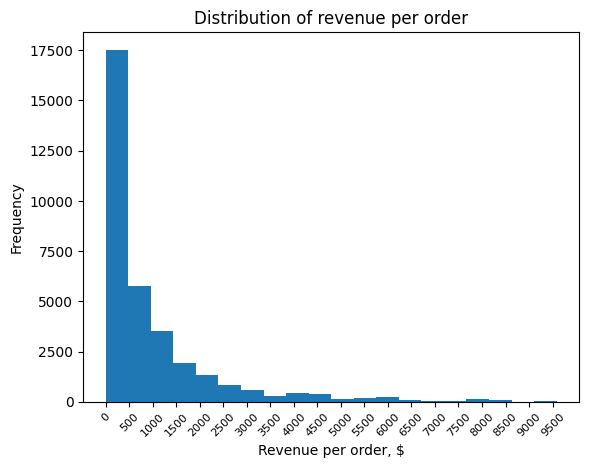

In [20]:
data_with_price.rename(columns = {"price": "revenue_per_order"}, inplace=True) # Rename column 'price'

#Histogram of Price Distribution

plt.hist(data_with_price["revenue_per_order"],bins = 20)
plt.title("Distribution of revenue per order")
plt.xlabel("Revenue per order, $")
plt.ylabel("Frequency")
x_ticks = np.arange(0, data_with_price["revenue_per_order"].max() + 415, 500)
plt.xticks(x_ticks, rotation = 45, fontsize=8)
plt.show()

In [102]:
data_with_purchase_less_one_twentieth_part = data[data["price"] <= data["price"].max() / 20]

number_of_purchase_less_one_twentieth_part = data_with_purchase_less_one_twentieth_part["price"].count()
print("The total number of orders amounted to\nЗагальна кількість замовлень становила", data["price"].count())
print("\nThe value of the majority of orders falls within the range from $0 to $", data["price"].max() / 20, "\nВартість переважної кількості замовлень знаходиться в діапазоні від $ 0 до $", data["price"].max() / 20,". \n\nThe number of such orders is\nКількість таких замовлень дорівнює", number_of_purchase_less_one_twentieth_part,",")
print("\n\nwhich accounts for", round(number_of_purchase_less_one_twentieth_part / data["price"].count() * 100, 0), "% from toral order number \nщо складає", round(number_of_purchase_less_one_twentieth_part / data["price"].count() * 100, 0),"% від загальної кількості замовлень.")


The total number of orders amounted to
Загальна кількість замовлень становила 33538

The value of the majority of orders falls within the range from $0 to $ 479.25 
Вартість переважної кількості замовлень знаходиться в діапазоні від $ 0 до $ 479.25 . 

The number of such orders is
Кількість таких замовлень дорівнює 17492 ,


which accounts for 52.0 % from toral order number 
що складає 52.0 % від загальної кількості замовлень.


In [22]:
print("During the evaluated period, the total sales amounted to\nУ періоді, що оцінюється, загальна сума продажів склала $", round(data["price"].sum(), 2))
#print()

During the evaluated period, the total sales amounted to
У періоді, що оцінюється, загальна сума продажів склала $ 31971731.1


In [23]:
#pivot table (revenue by continents)
data_pivot_table = pd.pivot_table(data, values = "price", columns = "continent", aggfunc = "sum")
print(data_pivot_table)

continent  (not set)    Africa    Americas       Asia     Europe   Oceania
price        74067.4  331231.0  17665280.0  7601298.3  5934624.2  365230.2


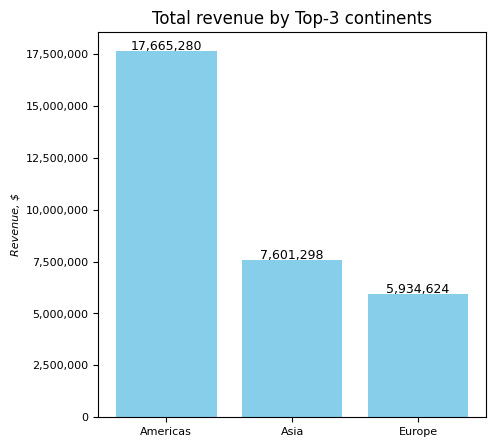

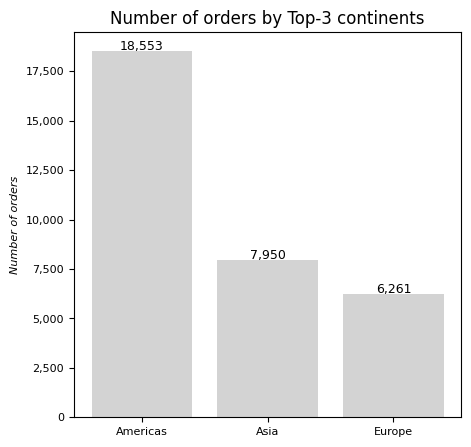

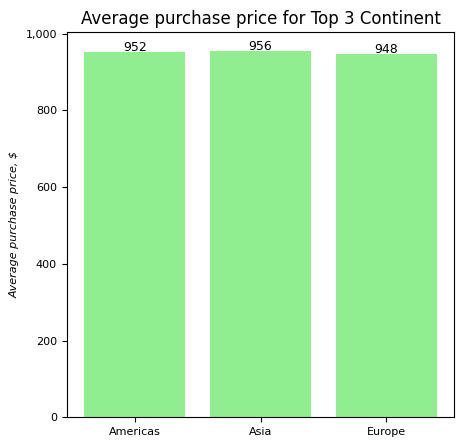

In [24]:
#Bar chart: "Total revenue by Top-3 continents"
#"Загальний дохід по Топ 3 континентам"
data_orders = data[data["price"].notna()]
data_revenue_orders_by_continent = data_orders.groupby("continent")["price"].agg(["sum","count"]).sort_values(by = "sum", ascending = False).reset_index()[:3]
data_revenue_orders_by_continent["avg_price"] = (data_revenue_orders_by_continent["sum"] / data_revenue_orders_by_continent["count"]).round(0).astype(int)

plt.figure(figsize=(5, 5))
bars = plt.bar(data_revenue_orders_by_continent["continent"], data_revenue_orders_by_continent["sum"], color="skyblue")
plt.title("Total revenue by Top-3 continents")
plt.xlabel("", fontsize=8, fontstyle="italic")
plt.ylabel("Revenue, $", fontsize=8, fontstyle="italic")
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
# numbers on the y-axis
plt.gca().get_yaxis().set_major_formatter(ticker.FuncFormatter(lambda y, _: f"{int(y):,}"))

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() - 100000,
        f"{int(bar.get_height()):,}",
        ha="center",
        va="bottom",
        color="black",
        fontsize=9,
    )

plt.show()

#Bar chart: "Number of orders by Top 3 continents"
#data_orders = data[data["category"].notna()]
data_orders_by_continent = data_orders.groupby("continent")["price"].agg(["sum","count"]).sort_values(by = "count", ascending = False).reset_index()[:3]

plt.figure(figsize=(5, 5))
bars = plt.bar(data_orders_by_continent["continent"], data_orders_by_continent["count"], color="lightgrey")
plt.title("Number of orders by Top-3 continents")
plt.xlabel("", fontsize=8, fontstyle="italic")
plt.ylabel("Number of orders", fontsize=8, fontstyle="italic")
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
# numbers on the y-axis
plt.gca().get_yaxis().set_major_formatter(ticker.FuncFormatter(lambda y, _: f"{int(y):,}"))

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() - 100,
        f"{int(bar.get_height()):,}",
        ha="center",
        va="bottom",
        color="black",
        fontsize=9,
    )

plt.show()

#Bar chart: "Average purchase price for Top 3 Continent (by revenue)"

plt.figure(figsize=(5, 5))
bars = plt.bar(data_revenue_orders_by_continent["continent"], data_revenue_orders_by_continent["avg_price"], color="lightgreen")
plt.title("Average purchase price for Top 3 Continent") # (за доходом)")
plt.xlabel("", fontsize=8, fontstyle="italic")
plt.ylabel("Average purchase price, $", fontsize=8, fontstyle="italic")
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
# numbers on the y-axis
plt.gca().get_yaxis().set_major_formatter(ticker.FuncFormatter(lambda y, _: f"{int(y):,}"))

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() - 5,
        f"{int(bar.get_height()):,}",
        ha="center",
        va="bottom",
        color="black",
        fontsize=9,
    )

plt.show()



###The highest revenue ($17,665,280), as well as the largest number of orders (18,553), came from sales to consumers in the Americas. Overall, the top three continents by revenue are the Americas, Asia, and Europe. The average order value on these continents does not differ significantly.

Найбільший рівень доходу ($ 17,665,280), як і кількість замовлень (18,553) принесли продажі споживачам на континенті Америка. В цілому, топ-3 континентами за розміром доходу є Америка, Азія та Європа. Середня вартість замовлення на цих континентах відрізняється несуттєво.

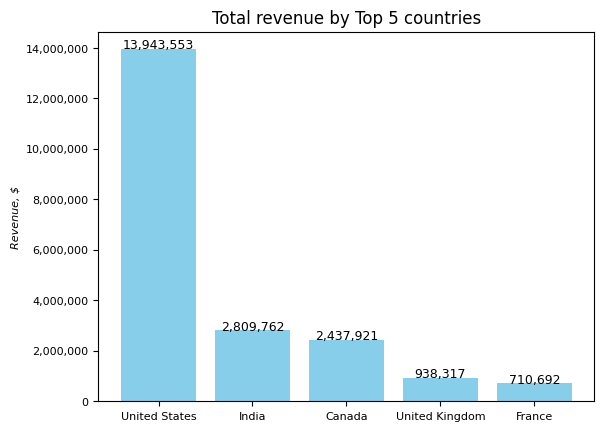

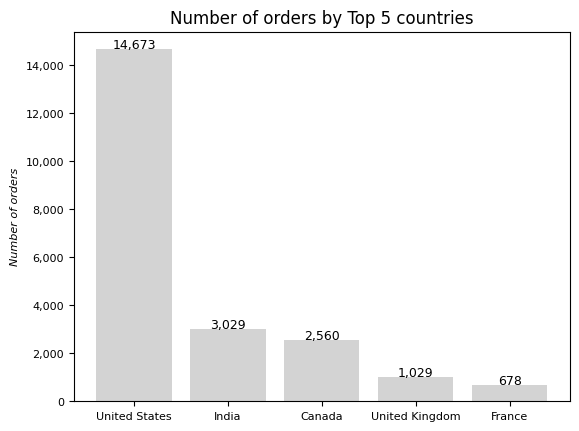

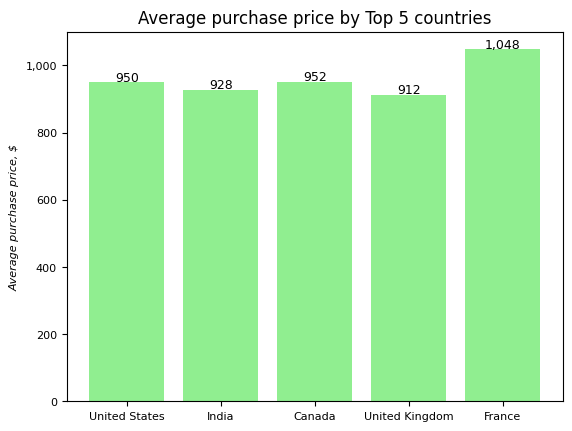

In [25]:
data_revenue_orders_by_countries = (
    data_orders.groupby("country")["price"]
    .agg(["sum","count"])
    .sort_values(by = "sum", ascending=False)[:5]
    .reset_index()
)
data_revenue_orders_by_countries["avg_price"] = (data_revenue_orders_by_countries["sum"] / data_revenue_orders_by_countries["count"]).round(0).astype(int)


#Bar chart: "Total revenue by Top 5 countries"
bars = plt.bar(data_revenue_orders_by_countries["country"], data_revenue_orders_by_countries["sum"], color="skyblue")
plt.title("Total revenue by Top 5 countries")
plt.xlabel("", fontsize=8, fontstyle="italic")
plt.ylabel("Revenue, $", fontsize=8, fontstyle="italic")
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
# numbers on the y-axis
plt.gca().get_yaxis().set_major_formatter(ticker.FuncFormatter(lambda y, _: f"{int(y):,}"))

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() - 100000,
        f"{int(bar.get_height()):,}",
        ha="center",
        va="bottom",
        color="black",
        fontsize=9,
    )

plt.show()


data_revenue_orders_by_countries_top_orders = (
    data_orders.groupby("country")["price"]
    .agg(["sum","count"])
    .sort_values(by = "count", ascending=False)[:5]
    .reset_index()
)

data_revenue_orders_by_countries_top_orders["avg_price"] = (data_revenue_orders_by_countries_top_orders["sum"] / data_revenue_orders_by_countries_top_orders["count"]).round(0).astype(int)



#Bar chart: "Number of orders by Top 5 countries"
bars = plt.bar(data_revenue_orders_by_countries_top_orders["country"], data_revenue_orders_by_countries_top_orders["count"], color="lightgrey")
plt.title("Number of orders by Top 5 countries")
plt.xlabel("", fontsize=8, fontstyle="italic")
plt.ylabel("Number of orders", fontsize=8, fontstyle="italic")
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
# numbers on the y-axis
plt.gca().get_yaxis().set_major_formatter(ticker.FuncFormatter(lambda y, _: f"{int(y):,}"))

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() - 100,
        f"{int(bar.get_height()):,}",
        ha="center",
        va="bottom",
        color="black",
        fontsize=9,
    )

plt.show()


#Bar chart: "Average purchase price for Top 5 countries (by revenue)"
bars = plt.bar(data_revenue_orders_by_countries["country"], data_revenue_orders_by_countries["avg_price"], color="lightgreen")
plt.title("Average purchase price by Top 5 countries")
plt.xlabel("", fontsize=8, fontstyle="italic")
plt.ylabel("Average purchase price, $", fontsize=8, fontstyle="italic")
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
# numbers on the y-axis
plt.gca().get_yaxis().set_major_formatter(ticker.FuncFormatter(lambda y, _: f"{int(y):,}"))

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() - 5,
        f"{int(bar.get_height()):,}",
        ha="center",
        va="bottom",
        color="black",
        fontsize=9,
    )

plt.show()


###The key sales metrics by country can be seen in the figures above.  

The United States ranks first in both revenue ($13,943,553) and number of orders (14,673).  

However, the highest average order value was recorded in France ($1,048).

З основними показниками продажів в розрізі країн можна ознайомитись на вищевикладених малюнках.  

Сполучені Штати Америки займають перше місце, як за рівнем доходу ($13,943,553), так і за кількістю замовлень (14673).   
  
  Однак найбільший середній розмір замовлення зафіксовано у Франції ($1,048).


In [26]:
#data revenue by product categories
data_revenue_by_category = data_orders.groupby("category")["price"].agg(["sum","count"]).sort_values(by = "sum", ascending = False).reset_index()[:10]
data_revenue_by_category.rename(columns={"sum": "revenue"}, inplace=True)
data_revenue_by_category.index = range(1, len(data_revenue_by_category) + 1)

#Number formatting for columns with thousand separators
for col in ["revenue", "count"]:
    data_revenue_by_category[col] = data_revenue_by_category[col].apply(lambda x: f"{x:,.0f}")

data_revenue_by_category.head(10)

,category,revenue,count
1,Sofas & armchairs,"8,388,254","4,301"
2,Chairs,"6,147,749","5,952"
3,Beds,"4,919,725","2,926"
4,Bookcases & shelving units,"3,640,818","7,630"
5,Cabinets & cupboards,"2,336,500","2,318"
6,Outdoor furniture,"2,142,222","2,229"
7,Tables & desks,"1,790,308","2,941"
8,Chests of drawers & drawer units,"906,562","1,452"
9,Bar furniture,"735,503","1,092"
10,Children's furniture,"467,697","1,702"


In [27]:
#Revenue by categories for top one country (by total price)
data_orders_top_one_country =  data_orders.groupby("country")["price"].agg(["sum","count"]).sort_values(by = "sum", ascending=False).reset_index()[:1]
data_for_top_one_country_by_revenue = data_orders[(data_orders["country"] == data_orders_top_one_country["country"].iloc[0])]
data_revenue_by_category_for_top_one_country = data_for_top_one_country_by_revenue.groupby("category")["price"].agg(["sum", "count"]).sort_values(by = "sum", ascending = False).reset_index()[:10]
print("Найбільший рівень доходу отримано від продажів в", data_orders_top_one_country["country"].iloc[0])
print("Топ-10 категорій продукції за рівнем доходу в", data_orders_top_one_country["country"].iloc[0])
data_revenue_by_category_for_top_one_country.rename(columns = {"sum": "revenue"}, inplace = True)

data_revenue_by_category_for_top_one_country.index = range(1, len(data_revenue_by_category_for_top_one_country) + 1, 1)

# Number formatting for columns with thousand separators
for col in ["revenue", "count"]:
    data_revenue_by_category_for_top_one_country[col] = data_revenue_by_category_for_top_one_country[col].apply(lambda x: f"{x:,.0f}")

data_revenue_by_category_for_top_one_country.head(10)

Найбільший рівень доходу отримано від продажів в United States
Топ-10 категорій продукції за рівнем доходу в United States


,category,revenue,count
1,Sofas & armchairs,"3,707,144","1,903"
2,Chairs,"2,619,774","2,576"
3,Beds,"2,213,058","1,298"
4,Bookcases & shelving units,"1,567,607","3,374"
5,Cabinets & cupboards,"994,546",995
6,Outdoor furniture,"929,245",984
7,Tables & desks,"777,865","1,248"
8,Chests of drawers & drawer units,"382,388",616
9,Bar furniture,"330,805",487
10,Children's furniture,"207,575",752


    device         sum  count  percent_of_total_revenue  \
0  desktop  18864039.0  19702                      59.0   
1   mobile  12384225.8  13113                      38.7   
2   tablet    723466.3    723                       2.3   

   percent_of_total_number  
0                     58.7  
1                     39.1  
2                      2.2  


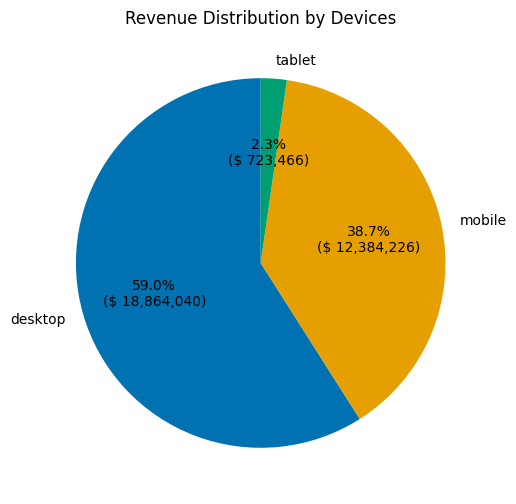

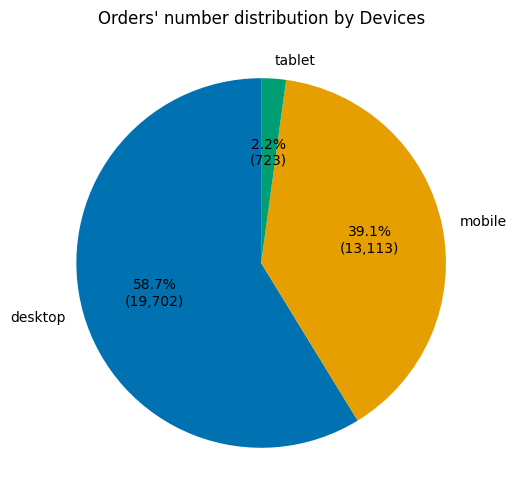

In [103]:
colors = ["#0072B2", "#E69F00", "#009E73", "#56B4E9", "#D55E00", "#CC79A7", "#F0E442"]

data_orders_by_devices = (
    data_orders.groupby("device")["price"]
    .agg(["sum","count"])
    .reset_index()
)


data_orders_by_devices["percent_of_total_revenue"] = (data_orders_by_devices["sum"] / data_orders["price"].sum() * 100).round(1)

data_orders_by_devices["percent_of_total_number"] = (data_orders_by_devices["count"] / data_orders["price"].count() * 100).round(1)

print(data_orders_by_devices.head())

labels = data_orders_by_devices["device"]
values = data_orders_by_devices["sum"]

# Pie Chart
plt.figure(figsize=(6, 6))

#Function to display both percentages and absolute numbers
def func(pct, allvals):
    absolute = int(round(pct/100 * sum(allvals)))
    return f"{pct:.1f}%\n($ {absolute:,})"

plt.pie(
    values,
    labels=labels,
    colors=colors[:len(labels)],
    autopct=lambda pct: func(pct, values),
    startangle=90,   # Starting angle
    shadow=False     # Adds a shadow
)

plt.title("Revenue Distribution by Devices")
plt.show()


labels = data_orders_by_devices["device"]
values2 = data_orders_by_devices["count"]


def func(pct, allvals):
    absolute = int(round(pct/100 * sum(allvals)))
    return f"{pct:.1f}%\n({absolute:,})"




plt.figure(figsize=(6, 6))
plt.pie(
    values2,
    labels=labels,
    colors=colors[:len(labels)],
    # autopct='%1.1f%%',  # Display percentages
    autopct=lambda pct: func(pct, values2),
    startangle=90,        # Starting angle
    # shadow=False         # Adds a shadow
)

plt.title("Orders' number distribution by Devices")
plt.show()


###By device type, the highest revenue ($18,864,039) and the largest number of orders (19,702) were generated by desktop users.

У розрізі девайсів максимальний дохід ($ 18,864,039.0) та максимальну кількість замовлень (19,702)  принесли користувачі десктопів


          channel         sum  count  percent_of_total_revenue  \
0          Direct   7494923.4   7800                      23.4   
1  Organic Search  11433151.6  11921                      35.8   
2     Paid Search   8511049.4   9042                      26.6   
3   Social Search   2532105.7   2716                       7.9   
4       Undefined   2000501.0   2059                       6.3   

   percent_of_total_number  
0                     23.3  
1                     35.5  
2                     27.0  
3                      8.1  
4                      6.1  


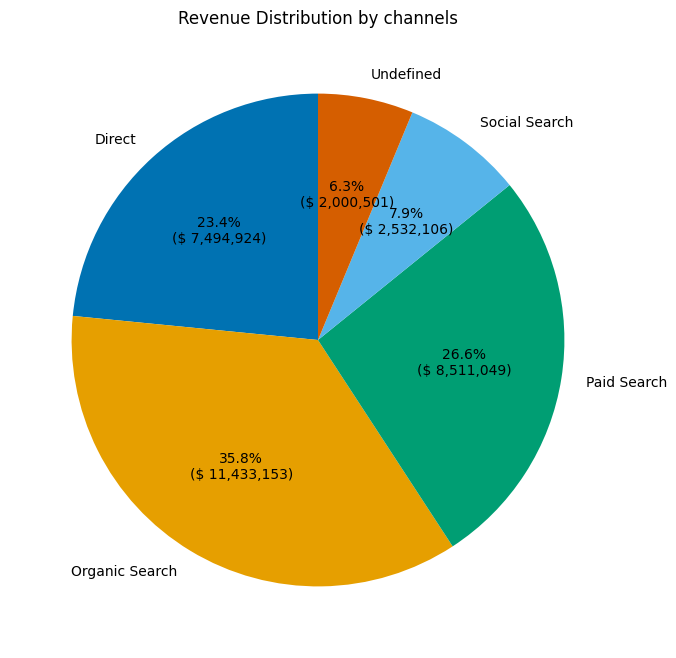

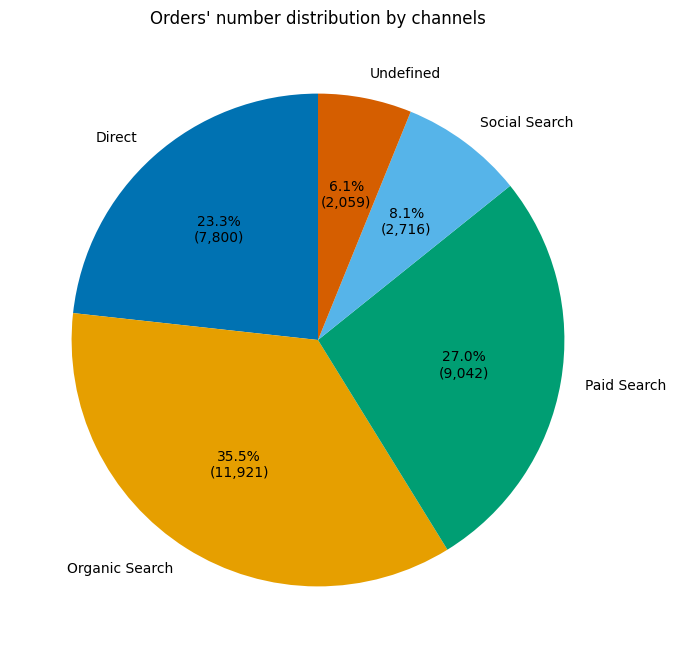

In [29]:
colors = ["#0072B2", "#E69F00", "#009E73", "#56B4E9", "#D55E00", "#CC79A7", "#F0E442"]


data_orders_by_channels = (
    data_orders.groupby("channel")["price"]
    .agg(["sum","count"])
    .reset_index()
)

data_orders_by_channels["percent_of_total_revenue"] = (data_orders_by_channels["sum"] / data_orders["price"].sum() * 100).round(1)

data_orders_by_channels["percent_of_total_number"] = (data_orders_by_channels["count"] / data_orders["price"].count() * 100).round(1)

print(data_orders_by_channels.head())

labels = data_orders_by_channels["channel"]
values = data_orders_by_channels["sum"]

# Pie Chart
plt.figure(figsize=(8, 8))

# Function to display both percentages and absolute numbers
def func(pct, allvals):
    absolute = int(round(pct/100 * sum(allvals)))
    return f"{pct:.1f}%\n($ {absolute:,})"

plt.pie(
    values,
    labels=labels,
    colors=colors[:len(labels)],
    autopct=lambda pct: func(pct, values),
    startangle=90,         # Start Angle
    #shadow=False            # to add shadow - True
)

plt.title("Revenue Distribution by channels")
plt.show()


labels = data_orders_by_channels["channel"]
values2 = data_orders_by_channels["count"]


def func(pct, allvals):
    absolute = int(round(pct/100 * sum(allvals)))
    return f"{pct:.1f}%\n({absolute:,})"

# Pie Chart


plt.figure(figsize=(8, 8))
plt.pie(
    values2,
    labels=labels,
    colors=colors[:len(labels)],
    #autopct='%1.1f%%', # to show %
    autopct=lambda pct: func(pct, values2),
    startangle=90,         # Start Angle
    shadow=False            # to add shadow - True
)

plt.title("Orders' number distribution by channels")
plt.show()


In [30]:

data_account = data[data['account_id'].notna()]
print("The number of registered users during the reporting period amounted to\nКількість зареєстрованих користувачів за звітний період склала", data_account.shape[0],",")
percent_is_verified = (data_account[data_account["is_verified"]==1].shape[0]) / (data_account.shape[0]) * 100
print("\nof which ", data_account[data_account["is_verified"]==1].shape[0], " (", round(percent_is_verified, 1), "%) verified their email address\nіз них ", data_account[data_account["is_verified"]==1].shape[0], "(",round(percent_is_verified, 1), "%) підтвердили свою електронну адресу")

percent_is_unsubscribed = (data_account[data_account['is_unsubscribed'] == 1].shape[0]) / (data_account.shape[0]) * 100
print("\nand ", data_account[data_account['is_unsubscribed'] == 1].shape[0], " (", round(percent_is_unsubscribed, 1), "%) unsubscribed from the mailing list.\nта ", (data_account[data_account['is_unsubscribed'] == 1].shape[0]), "(",round(percent_is_unsubscribed, 1), "%) відписались від розсилки.")



The number of registered users during the reporting period amounted to
Кількість зареєстрованих користувачів за звітний період склала 27945 ,

of which  20036  ( 71.7 %) verified their email address
із них  20036 ( 71.7 %) підтвердили свою електронну адресу

and  4735  ( 16.9 %) unsubscribed from the mailing list.
та  4735 ( 16.9 %) відписались від розсилки.


In [31]:
data_account[data_account['is_unsubscribed'] == 1].describe()

,date,ga_session_id,account_id,is_verified,is_unsubscribed,price
count,4735,4735.0,4735.0,4735.0,4735.0,447.000000
mean,2020-12-14 13:43:14.889123584,4225722696.293136,657133.078353,0.908976,1.0,965.820134
min,2020-11-01 00:00:00,343144.0,636133.0,0.0,1.0,3.000000
25%,2020-11-25 00:00:00,1817212562.0,646955.0,1.0,1.0,175.000000
50%,2020-12-13 00:00:00,3875087874.0,657219.0,1.0,1.0,450.000000
75%,2021-01-06 00:00:00,6470201474.5,666854.5,1.0,1.0,1297.500000
max,2021-01-27 00:00:00,9998760100.0,681845.0,1.0,1.0,8900.000000
std,NaN,2801127485.899683,12160.066077,0.287674,0.0,1298.176986


In [32]:
data_account[data_account['is_unsubscribed'] == 0].describe()

,date,ga_session_id,account_id,is_verified,is_unsubscribed,price
count,23210,23210.0,23210.0,23210.0,23210.0,2334.000000
mean,2020-12-14 18:17:09.280482560,4213253845.413701,659386.963852,0.677811,0.0,921.506812
min,2020-11-01 00:00:00,105278.0,636138.0,0.0,0.0,3.000000
25%,2020-11-25 00:00:00,1756677276.0,647687.5,0.0,0.0,149.000000
50%,2020-12-14 00:00:00,3845448524.5,659387.0,1.0,0.0,395.000000
75%,2021-01-06 00:00:00,6487199502.5,671170.5,1.0,0.0,1100.000000
max,2021-01-27 00:00:00,9999783761.0,681962.0,1.0,0.0,8900.000000
std,NaN,2833233543.516948,13389.987945,0.467325,0.0,1323.918182


In [33]:
print("The average order value for users who unsubscribed from the mailing list amounted to $", round(data_account[data_account['is_unsubscribed'] == 1]['price'].mean(), 1),"\nCередня вартість замовлень у користувачів, що відписались від розсилки, склала $", round(data_account[data_account['is_unsubscribed'] == 1]['price'].mean(),1))
print("\nThe average order value for users who did not unsubscribe from the mailing list amounted to $",
      round(data_account[data_account['is_unsubscribed'] == 0]['price'].mean(), 1))
print("Cередня вартість замовлень у користувачів, що не відписались від розсилки, склала $", round(data_account[data_account['is_unsubscribed'] == 0]['price'].mean(),1))

The average order value for users who unsubscribed from the mailing list amounted to $ 965.8 
Cередня вартість замовлень у користувачів, що відписались від розсилки, склала $ 965.8

The average order value for users who did not unsubscribe from the mailing list amounted to $ 921.5
Cередня вартість замовлень у користувачів, що не відписались від розсилки, склала $ 921.5


In [34]:
print("Number of countries where users are registered:", data_account['country'].nunique())
print("Кількість країн, в яких користувачі зареєстровані:", data_account['country'].nunique())

Number of countries where users are registered: 108
Кількість країн, в яких користувачі зареєстровані: 108


In [35]:
data_account_by_countries = data_account.groupby("country")["account_id"].agg(count = 'count').sort_values(by = 'count', ascending = False).reset_index().iloc[:10]
data_account_by_countries.index = range(1, len(data_account_by_countries) + 1)

#Formatting numerical columns with thousand separators
for col in ["count"]:
    data_account_by_countries[col] = data_account_by_countries[col].apply(lambda x: f"{x:>10,}")
#data_account_by_countries.rename(columns= {"count":"number of registered users"}, inplace = True)
data_account_by_countries.head(10)

,country,count
1,United States,"12,384"
2,India,"2,687"
3,Canada,"2,067"
4,United Kingdom,859
5,France,553
6,Spain,536
7,Taiwan,500
8,China,490
9,Germany,490
10,Italy,386


In [36]:
data_account_by_continents = data_account.groupby("continent")["account_id"].agg(count = 'count').sort_values(by = 'count', ascending = False).reset_index().iloc[:10]
data_account_by_continents.index = range(1, len(data_account_by_continents) + 1)

for col in ["count"]:
    data_account_by_continents[col] = data_account_by_continents[col].apply(lambda x: f"{x:>10,}")
#data_account_by_continents.rename(columns= {"count":"number of registered users"}, inplace = True)

data_account_by_continents.head(10)

,continent,count
1,Americas,"15,520"
2,Asia,"6,664"
3,Europe,"5,170"
4,Oceania,272
5,Africa,266
6,(not set),53


In [37]:
data_account_by_continents.info()
print(data_account_by_continents)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 1 to 6
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   continent  6 non-null      object
 1   count      6 non-null      object
dtypes: object(2)
memory usage: 228.0+ bytes
   continent       count
1   Americas      15,520
2       Asia       6,664
3     Europe       5,170
4    Oceania         272
5     Africa         266
6  (not set)          53


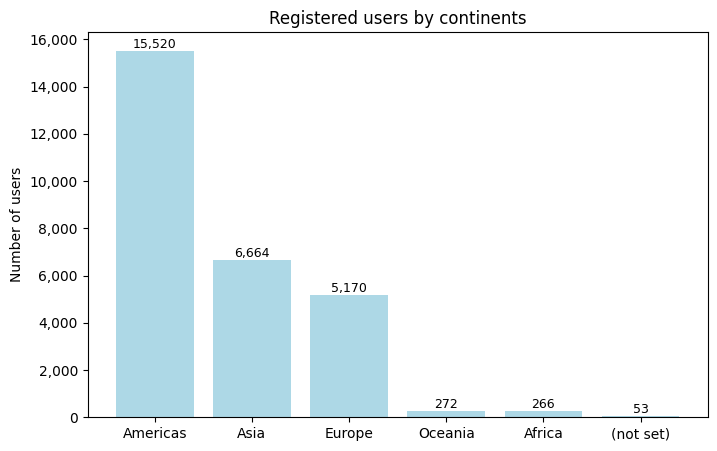

In [38]:

data_account_by_continents["count"] = (
    data_account_by_continents["count"]
    .replace({',': ''}, regex=True)
    .astype(int)
)

plt.figure(figsize=(8,5))
bars = plt.bar(data_account_by_continents["continent"], data_account_by_continents["count"], color = "lightblue")
plt.title("Registered users by continents")
plt.ylabel("Number of users")
plt.gca().get_yaxis().set_major_formatter(ticker.FuncFormatter(lambda y, _: f"{int(y):,}"))

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(bar.get_height()):,}",
        ha="center",
        va="bottom",
        color="black",
        fontsize=9,
    )



plt.show()


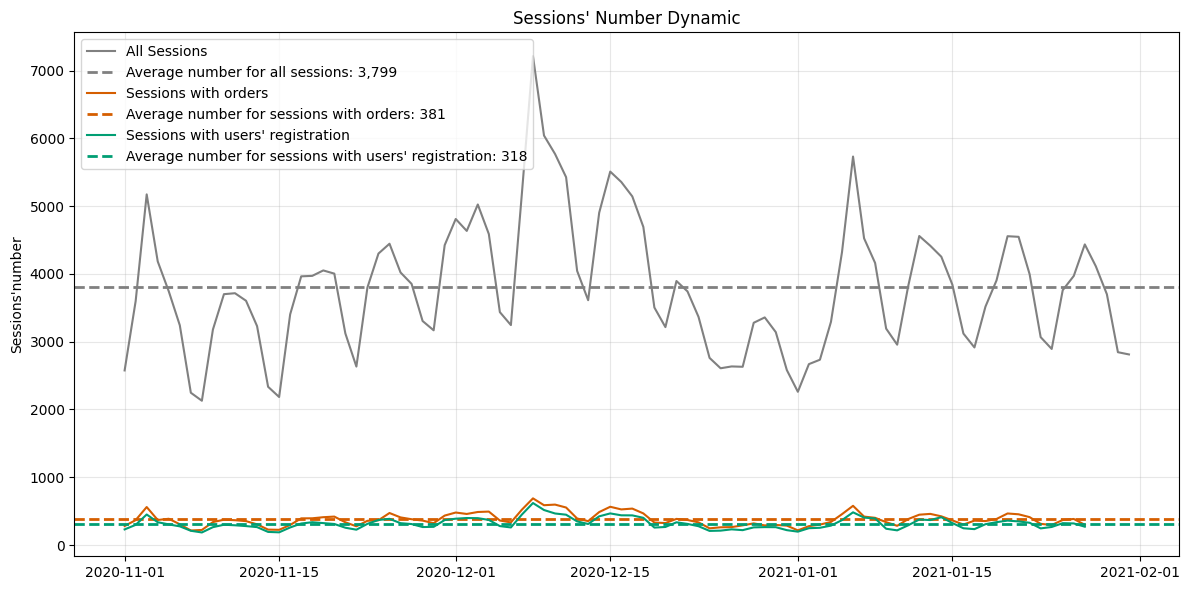

In [39]:
#All Sessions (Number)
plt.figure(figsize=(12, 6))

data_session_dynamic = data.groupby("date")["ga_session_id"].count().reset_index().sort_values(by = "date")
data_session_dynamic.head()

plt.plot(data_session_dynamic["date"], data_session_dynamic["ga_session_id"], label="All Sessions", color="grey")


mean_sessions_number = data_session_dynamic["ga_session_id"].mean()# Середнє значення з підписом у легенді
plt.axhline(y=mean_sessions_number, color="grey", linestyle="--", linewidth=2, label=f"Average number for all sessions: {mean_sessions_number:,.0f}")

plt.title("Sessions' Number Dynamic")
plt.xlabel("")
plt.ylabel("Sessions'number")
plt.xticks(rotation=0)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

#Sessions with orders (Number)

data_sessions_with_orders_dynamic = data_orders.groupby("date")["ga_session_id"].count().reset_index().sort_values(by = "date")

plt.plot(data_sessions_with_orders_dynamic["date"], data_sessions_with_orders_dynamic["ga_session_id"], label="Sessions with orders", color="#D55E00")


mean_account_sessions_with_orders_number = data_sessions_with_orders_dynamic["ga_session_id"].mean()# Середнє значення з підписом у легенді
plt.axhline(y=mean_account_sessions_with_orders_number, color="#D55E00", linestyle="--", linewidth=2, label=f"Average number for sessions with orders: {mean_account_sessions_with_orders_number:,.0f}")

#plt.title("Sessions' Number Dynamic")
#plt.xlabel("")
#plt.ylabel("Sessions'number")
#plt.xticks(rotation=0)
#plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()



#Sessions with users registration (Number)

data_account_session = data[data["account_id"].notna()]

data_account_session_dynamic = data_account_session.groupby("date")["ga_session_id"].count().reset_index().sort_values(by = "date")
data_account_session_dynamic.head()

plt.plot(data_account_session_dynamic["date"], data_account_session_dynamic["ga_session_id"], label="Sessions with users' registration", color="#009E73")


mean_account_sessions_number = data_account_session_dynamic["ga_session_id"].mean()# Середнє значення з підписом у легенді
plt.axhline(y=mean_account_sessions_number, color="#009E73", linestyle="--", linewidth=2, label=f"Average number for sessions with users' registration: {mean_account_sessions_number:,.0f}")

#plt.title("Sessions' Number Dynamic")
#plt.xlabel("")
#plt.ylabel("Sessions'number")
#plt.xticks(rotation=0)
#plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()





plt.show()


#**Sales dynamics analysis**
Аналіз динаміки продажів


In [40]:
data_orders_dynamic = data_orders.groupby("date")["price"].sum().reset_index().sort_values(by = "date", ascending = True)
data_orders_dynamic.head()

,date,price
0,2020-11-01,244292.5
1,2020-11-02,355506.8
2,2020-11-03,498979.6
3,2020-11-04,339187.1
4,2020-11-05,391276.6


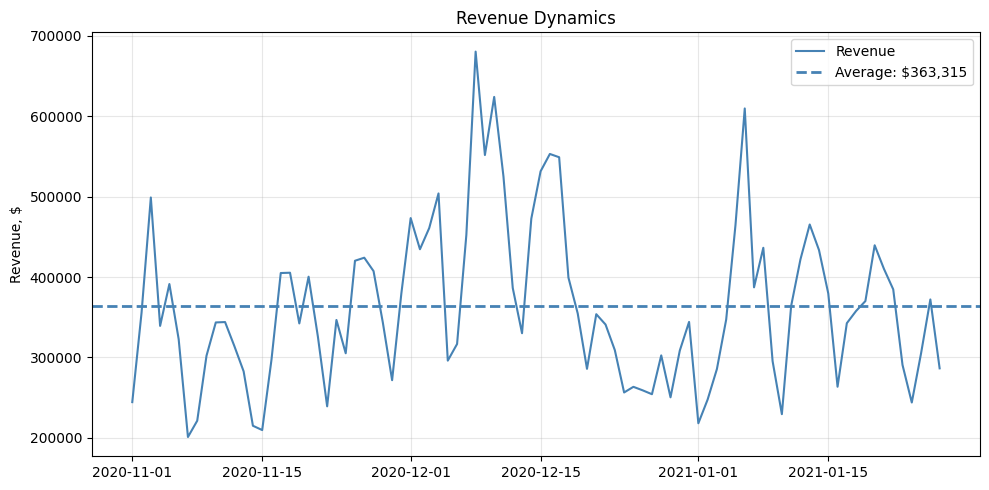

In [41]:

plt.figure(figsize=(10, 5))
plt.plot(data_orders_dynamic["date"], data_orders_dynamic["price"], label="Revenue", color="steelblue")

# Average value with a label in the legend
mean_revenue = data_orders_dynamic["price"].mean()
plt.axhline(y=mean_revenue, color="steelblue", linestyle="--", linewidth=2, label=f"Average: ${mean_revenue:,.0f}")

plt.title("Revenue Dynamics")
plt.xlabel("")
plt.ylabel("Revenue, $")
plt.xticks(rotation=0)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


month
11     9897515.0
12    12423439.3
1      9650776.8
2            0.0
3            0.0
Name: price, dtype: float64


/tmp/ipython-input-3980805831.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_orders["month"] = data_orders["date"].dt.month
/tmp/ipython-input-3980805831.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_orders["month"] = pd.Categorical(data_orders["month"], categories=month_order, ordered=True)
/tmp/ipython-input-3980805831.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavi

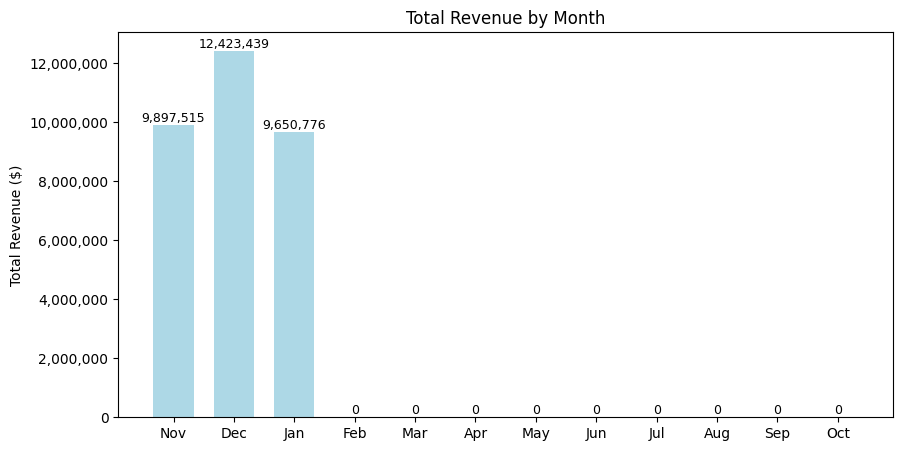

In [42]:

#data_orders.loc[:, "day_of_week"] = data_orders["date"].dt.dayofweek

data_orders["month"] = data_orders["date"].dt.month
month_order = [11, 12, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
month_names = ['Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct']

data_orders["month"] = pd.Categorical(data_orders["month"], categories=month_order, ordered=True)
monthly_revenue = data_orders.groupby("month")["price"].sum().reindex(month_order)
print(monthly_revenue.head())

plt.figure(figsize=(10, 5))


x = np.arange(len(month_names)) * 1.2
bars = plt.bar(x, monthly_revenue, color="lightblue", width=0.8)
plt.xticks(x, month_names)


plt.title("Total Revenue by Month")
plt.ylabel("Total Revenue ($)")
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(bar.get_height()):,}",
        ha="center",
        va="bottom",
        color="black",
        fontsize=9,
    )


plt.show()

day_of_week
0    4636290.4
1    5457515.9
2    5466542.9
3    4936935.6
4    4523067.2
Name: price, dtype: float64


/tmp/ipython-input-3182645462.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_orders["day_of_week"] = data_orders["date"].dt.dayofweek
/tmp/ipython-input-3182645462.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_orders["day_of_week"] = pd.Categorical(data_orders["day_of_week"], categories=day_order, ordered=True)
/tmp/ipython-input-3182645462.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to r

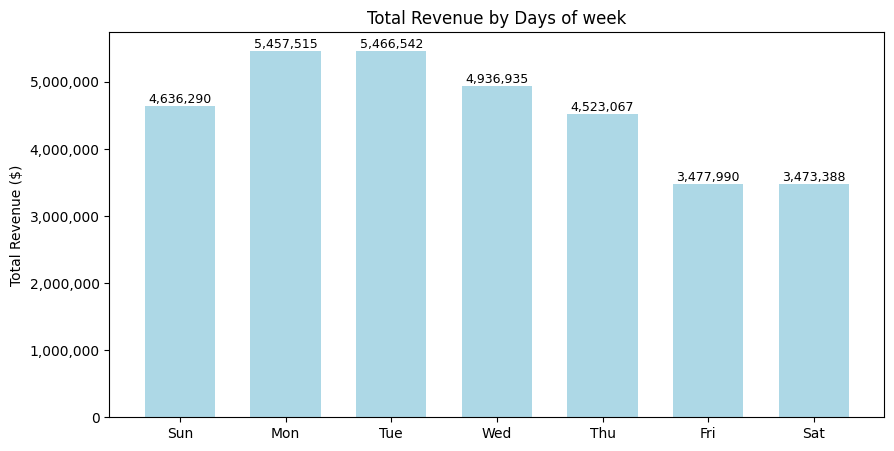

In [43]:


data_orders["day_of_week"] = data_orders["date"].dt.dayofweek

#data_orders["month"] = data_orders["date"].dt.month
day_order = [0, 1, 2, 3, 4, 5, 6]
day_names = ['Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']

data_orders["day_of_week"] = pd.Categorical(data_orders["day_of_week"], categories=day_order, ordered=True)
day_of_week_revenue = data_orders.groupby("day_of_week")["price"].sum().reindex(day_order)
print(day_of_week_revenue.head())

plt.figure(figsize=(10, 5))


x = np.arange(len(day_names)) * 1.2
bars = plt.bar(x, day_of_week_revenue, color="lightblue", width=0.8)
plt.xticks(x, day_names)

plt.title("Total Revenue by Days of week")
plt.ylabel("Total Revenue ($)")
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(bar.get_height()):,}",
        ha="center",
        va="bottom",
        color="black",
        fontsize=9,
    )


plt.show()

        date     price
0 2020-11-01  132002.5
1 2020-11-02  193861.0
2 2020-11-03  294529.8
3 2020-11-04  200009.5
4 2020-11-05  182988.2
        date     price
0 2020-11-01   63823.0
1 2020-11-02   79370.0
2 2020-11-03  126737.8
3 2020-11-04   66602.0
4 2020-11-05  117608.4
        date    price
0 2020-11-01  46908.0
1 2020-11-02  75710.8
2 2020-11-03  67692.0
3 2020-11-04  65915.0
4 2020-11-05  86540.0


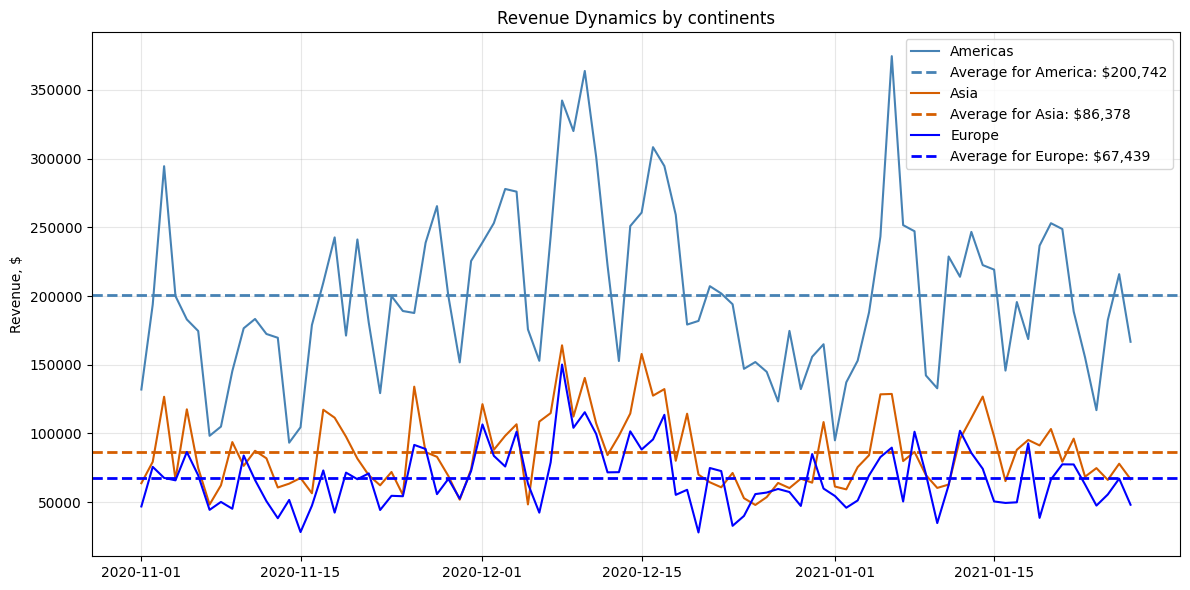

In [44]:

data_orders_dynamic_America = data_orders[data_orders["continent"] == "Americas"].groupby("date")["price"].sum().reset_index().sort_values(by = "date", ascending = True)
print(data_orders_dynamic_America.head())

plt.figure(figsize=(12, 6))
plt.plot(data_orders_dynamic_America["date"], data_orders_dynamic_America["price"], label="Americas", color="steelblue")

# Середнє значення з підписом у легенді
mean_revenue_America = data_orders_dynamic_America["price"].mean()
plt.axhline(y=mean_revenue_America, color="steelblue", linestyle="--", linewidth=2, label=f"Average for America: ${mean_revenue_America:,.0f}")

plt.title("Revenue Dynamics by continents")
plt.xlabel("")
plt.ylabel("Revenue, $")
plt.xticks(rotation=0)
plt.grid(alpha=0.3)
plt.legend()  # Легенда показується на графіку
plt.tight_layout()


data_orders_dynamic_Asia = data_orders[data_orders["continent"] == "Asia"].groupby("date")["price"].sum().reset_index().sort_values(by = "date", ascending = True)
print(data_orders_dynamic_Asia.head())

#plt.figure(figsize=(10, 5))
plt.plot(data_orders_dynamic_Asia["date"], data_orders_dynamic_Asia["price"], label="Asia", color="#D55E00")

# Середнє значення з підписом у легенді
mean_revenue_Asia = data_orders_dynamic_Asia["price"].mean()
plt.axhline(y=mean_revenue_Asia, color="#D55E00", linestyle="--", linewidth=2, label=f"Average for Asia: ${mean_revenue_Asia:,.0f}")

#plt.title("Revenue Dynamics for America (with total Average Line)")
#plt.xlabel("")
#plt.ylabel("Revenue, $")
#plt.xticks(rotation=90)
plt.grid(alpha=0.3)
plt.legend()  # Легенда показується на графіку
plt.tight_layout()



data_orders_dynamic_Europe = data_orders[data_orders["continent"] == "Europe"].groupby("date")["price"].sum().reset_index().sort_values(by = "date", ascending = True)
print(data_orders_dynamic_Europe.head())

#plt.figure(figsize=(10, 5))
plt.plot(data_orders_dynamic_Europe["date"], data_orders_dynamic_Europe["price"], label="Europe", color="blue")

# Середнє значення з підписом у легенді
mean_revenue_Europe = data_orders_dynamic_Europe["price"].mean()
plt.axhline(y=mean_revenue_Europe, color="blue", linestyle="--", linewidth=2, label=f"Average for Europe: ${mean_revenue_Europe:,.0f}")

#plt.title("Revenue Dynamics for America (with total Average Line)")
#plt.xlabel("")
#plt.ylabel("Revenue, $")
#plt.xticks(rotation=90)
plt.grid(alpha=0.3)
plt.legend()  # Легенда показується на графіку
plt.tight_layout()




plt.show()


In [45]:
data_orders["channel"].unique()

array(['Paid Search', 'Organic Search', 'Direct', 'Undefined',
       'Social Search'], dtype=object)

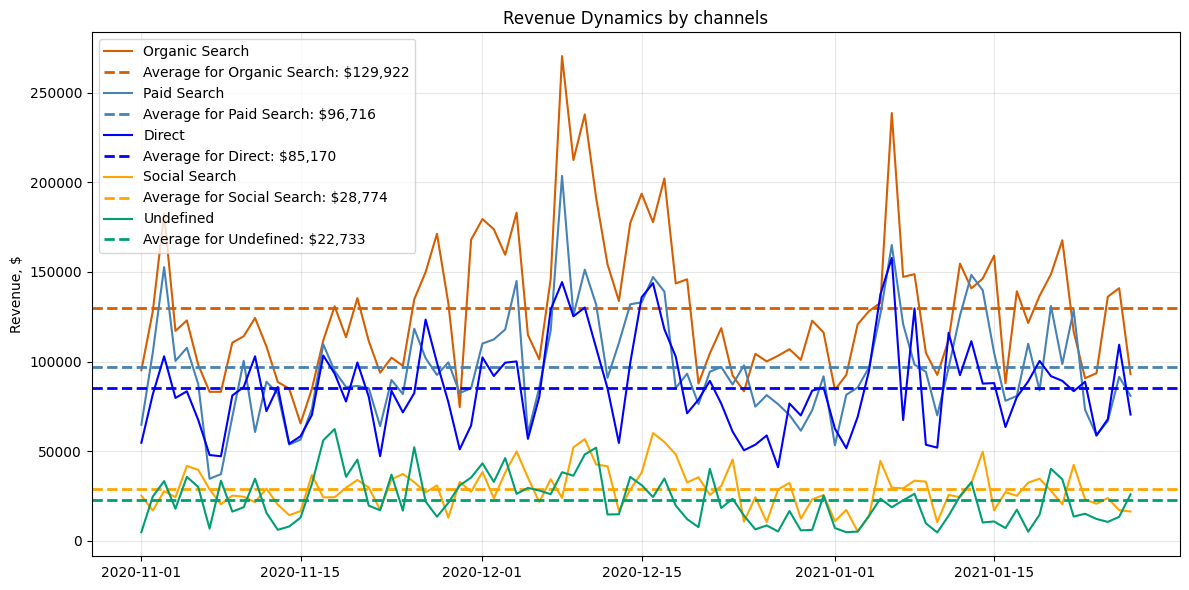

In [46]:
#Organic Search channel

data_orders_dynamic_organic_search = data_orders[data_orders["channel"] == "Organic Search"].groupby("date")["price"].sum().reset_index().sort_values(by = "date", ascending = True)
#print(data_orders_dynamic_organic_search.head())

plt.figure(figsize=(12, 6))
plt.plot(data_orders_dynamic_organic_search["date"], data_orders_dynamic_organic_search["price"], label="Organic Search", color="#D55E00")


mean_revenue_organic_search = data_orders_dynamic_organic_search["price"].mean()# Середнє значення з підписом у легенді
plt.axhline(y=mean_revenue_organic_search, color="#D55E00", linestyle="--", linewidth=2, label=f"Average for Organic Search: ${mean_revenue_organic_search:,.0f}")

plt.title("Revenue Dynamics by channels")
plt.xlabel("")
plt.ylabel("Revenue, $")
plt.xticks(rotation=0)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()


#Paid Search channel

data_orders_dynamic_paid_search = data_orders[data_orders["channel"] == "Paid Search"].groupby("date")["price"].sum().reset_index().sort_values(by = "date", ascending = True)

plt.plot(data_orders_dynamic_paid_search["date"], data_orders_dynamic_paid_search["price"], label="Paid Search", color="steelblue")

mean_revenue_paid_search = data_orders_dynamic_paid_search["price"].mean()# Середнє значення з підписом у легенді
plt.axhline(y=mean_revenue_paid_search, color="steelblue", linestyle="--", linewidth=2, label=f"Average for Paid Search: ${mean_revenue_paid_search:,.0f}")
plt.legend()
plt.tight_layout()




#Direct channel

data_orders_dynamic_direct = data_orders[data_orders["channel"] == "Direct"].groupby("date")["price"].sum().reset_index().sort_values(by = "date", ascending = True)

plt.plot(data_orders_dynamic_direct["date"], data_orders_dynamic_direct["price"], label="Direct", color="blue")


mean_revenue_direct = data_orders_dynamic_direct["price"].mean()
plt.axhline(y=mean_revenue_direct, color="blue", linestyle="--", linewidth=2, label=f"Average for Direct: ${mean_revenue_direct:,.0f}")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()


#Social Search channel
data_orders_dynamic_social_search = data_orders[data_orders["channel"] == "Social Search"].groupby("date")["price"].sum().reset_index().sort_values(by = "date", ascending = True)

plt.plot(data_orders_dynamic_social_search["date"], data_orders_dynamic_social_search["price"], label="Social Search", color="orange")

mean_revenue_social_search = data_orders_dynamic_social_search["price"].mean()

plt.axhline(y=mean_revenue_social_search, color="orange", linestyle="--", linewidth=2, label=f"Average for Social Search: ${mean_revenue_social_search:,.0f}")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()




#Undefined channel
data_orders_dynamic_undefined = data_orders[data_orders["channel"] == "Undefined"].groupby("date")["price"].sum().reset_index().sort_values(by = "date", ascending = True)

plt.plot(data_orders_dynamic_undefined["date"], data_orders_dynamic_undefined["price"], label="Undefined", color="#009E73")


mean_revenue_undefined = data_orders_dynamic_undefined["price"].mean()
plt.axhline(y=mean_revenue_undefined, color="#009E73", linestyle="--", linewidth=2, label=f"Average for Undefined: ${mean_revenue_undefined:,.0f}")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()



In [47]:
data_orders["device"].unique()

array(['desktop', 'mobile', 'tablet'], dtype=object)

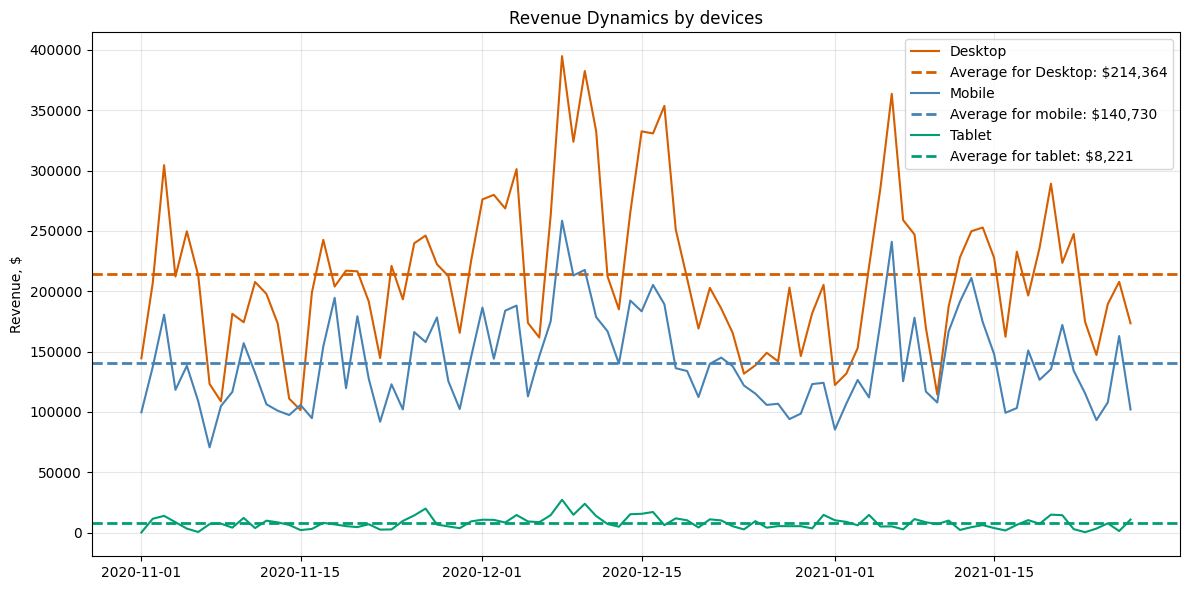

In [48]:
#Device Desktop

data_orders_dynamic_desktop = data_orders[data_orders["device"] == "desktop"].groupby("date")["price"].sum().reset_index().sort_values(by = "date", ascending = True)

plt.figure(figsize=(12, 6))
plt.plot(data_orders_dynamic_desktop["date"], data_orders_dynamic_desktop["price"], label="Desktop", color="#D55E00")

mean_revenue_desktop = data_orders_dynamic_desktop["price"].mean() # Середнє значення з підписом у легенді

plt.axhline(y=mean_revenue_desktop, color="#D55E00", linestyle="--", linewidth=2, label=f"Average for Desktop: ${mean_revenue_desktop:,.0f}")
plt.title("Revenue Dynamics by devices")
plt.xlabel("")
plt.ylabel("Revenue, $")
plt.xticks(rotation=0)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()


#Mobile device

data_orders_dynamic_mobile = data_orders[data_orders["device"] == "mobile"].groupby("date")["price"].sum().reset_index().sort_values(by = "date", ascending = True)

plt.plot(data_orders_dynamic_mobile["date"], data_orders_dynamic_mobile["price"], label="Mobile", color="steelblue")

mean_revenue_mobile = data_orders_dynamic_mobile["price"].mean()# Середнє значення з підписом у легенді
plt.axhline(y=mean_revenue_mobile, color="steelblue", linestyle="--", linewidth=2, label=f"Average for mobile: ${mean_revenue_mobile:,.0f}")
plt.legend()
plt.tight_layout()



#Tablet channel

data_orders_dynamic_tablet = data_orders[data_orders["device"] == "tablet"].groupby("date")["price"].sum().reset_index().sort_values(by = "date", ascending = True)
#print(data_orders_dynamic_tablet.head())

plt.plot(data_orders_dynamic_tablet["date"], data_orders_dynamic_tablet["price"], label="Tablet", color="#009E73")

mean_revenue_tablet = data_orders_dynamic_tablet["price"].mean() # Середнє значення з підписом у легенді
plt.axhline(y=mean_revenue_tablet, color="#009E73", linestyle="--", linewidth=2, label=f"Average for tablet: ${mean_revenue_tablet:,.0f}")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()


In [49]:
data_revenue_by_channel_pivot = pd.pivot_table(data,values = "ga_session_id", index = "channel", aggfunc = "count").reset_index().sort_values(by = "ga_session_id", ascending = False)
data_revenue_by_channel_pivot.rename(columns = {"ga_session_id":"number_of_sessions"}, inplace = True)
print(data_revenue_by_channel_pivot.to_string(index=False))


       channel  number_of_sessions
Organic Search              124425
   Paid Search               94341
        Direct               81382
 Social Search               27914
     Undefined               21483


##The charts show the presence of seasonal patterns, likely on a weekly basis, with customer activity increasing on certain days of the week. In addition, several notable spikes in customer activity are observed in mid-December and early January, which are likely related to promotions or sales events.
На графіках видно наявність сезонних патернів, імовірно, тижневої сезонності, коли активність клієнтів зростає у певні дні тижня. Крім того, фіксуються декілька значних сплесків активності клієнтів в середині грудня та на початку січня, які, ймовірно, пов’язані з акціями чи розпродажами.

In [50]:
#PIVOT TABLE

# Усі сесії
all_sessions = (
    pd.pivot_table(data, values="ga_session_id", index="channel", aggfunc="count")
    .rename(columns={"ga_session_id": "number_of_sessions"})
)

# Сесії з замовленнями
sessions_with_orders = (
    pd.pivot_table(data_orders, values="ga_session_id", index="channel", aggfunc="count")
    .rename(columns={"ga_session_id": "sessions_with_orders"})
)

# Сесії з реєстраціями
sessions_with_registrations = (
    pd.pivot_table(data_account_session, values="ga_session_id", index="channel", aggfunc="count")
    .rename(columns={"ga_session_id": "sessions_with_registrations"})
)

# Об’єднання всіх у спільну таблицю
data_revenue_by_channel_pivot = (
    all_sessions
    .merge(sessions_with_orders, on="channel", how="left")
    .merge(sessions_with_registrations, on="channel", how="left")
    .fillna(0)
    .reset_index()
    .sort_values(by="number_of_sessions", ascending=False)
)

print(data_revenue_by_channel_pivot.to_string(index=False))

       channel  number_of_sessions  sessions_with_orders  sessions_with_registrations
Organic Search              124425                 11921                        10035
   Paid Search               94341                  9042                         7467
        Direct               81382                  7800                         6514
 Social Search               27914                  2716                         2212
     Undefined               21483                  2059                         1717


In [51]:
#PIVOT TABLE


all_sessions_by_devices = (
    pd.pivot_table(data, values="ga_session_id", index="device", aggfunc="count")
    .rename(columns={"ga_session_id": "number_of_sessions"})
)

sessions_with_orders_by_devices = (
    pd.pivot_table(data_orders, values="ga_session_id", index="device", aggfunc="count")
    .rename(columns={"ga_session_id": "sessions_with_orders"})
)

sessions_with_registrations_by_devices = (
    pd.pivot_table(data_account_session, values="ga_session_id", index="device", aggfunc="count")
    .rename(columns={"ga_session_id": "sessions_with_registrations"})
)

data_revenue_by_devices_pivot = (
    all_sessions_by_devices
    .merge(sessions_with_orders_by_devices, on="device", how="left")
    .merge(sessions_with_registrations_by_devices, on="device", how="left")
    .fillna(0)
    .reset_index()
    .sort_values(by="number_of_sessions", ascending=False)
)

print(data_revenue_by_devices_pivot.to_string(index=False))

 device  number_of_sessions  sessions_with_orders  sessions_with_registrations
desktop              204429                 19702                        16417
 mobile              137267                 13113                        10878
 tablet                7849                   723                          650


In [52]:
sessions_with_orders_by_devices_channels = pd.pivot_table(data_orders, values="ga_session_id", index="channel", columns="device", aggfunc="count", margins=True, margins_name="Total").rename(columns={"ga_session_id": "sessions_with_orders"})
print(sessions_with_orders_by_devices_channels)

device          desktop  mobile  tablet  Total
channel                                       
Direct             4655    2985     160   7800
Organic Search     7011    4655     255  11921
Paid Search        5261    3574     207   9042
Social Search      1594    1065      57   2716
Undefined          1181     834      44   2059
Total             19702   13113     723  33538


In [53]:
#data_revenue_by_category = data_orders.groupby("category")["price"].agg(["sum","count"]).sort_values(by = "sum", ascending = False).reset_index()[:10]
#data_revenue_by_category.rename(columns={"sum": "revenue"}, inplace=True)
#data_revenue_by_category.index = range(1, len(data_revenue_by_category) + 1)

data_orders_10categories = data_orders[data_orders["category"].isin(data_revenue_by_category["category"])]
data_orders_10categories_5countries = data_orders_10categories[data_orders_10categories["country"].isin(data_revenue_orders_by_countries["country"])]
print(data_orders_10categories_5countries["country"].unique())
print(data_orders_10categories_5countries["category"].unique())

['United States' 'United Kingdom' 'Canada' 'India' 'France']
['Bookcases & shelving units' 'Bar furniture' 'Chairs'
 'Cabinets & cupboards' 'Outdoor furniture' 'Beds'
 'Chests of drawers & drawer units' 'Tables & desks' 'Sofas & armchairs'
 "Children's furniture"]


In [54]:
sessions_with_orders_by_10categories_5countries = pd.pivot_table(data_orders_10categories_5countries, values="price", index="category", columns="country", aggfunc="sum", margins=True, margins_name="Total").rename(columns={"price": "revenue"})
# Choose columns excluding 'Total'
country_cols = [c for c in sessions_with_orders_by_10categories_5countries.columns if c != "Total"]

# Сортуємо колонки за сумою по країні (спадання)
country_cols_sorted = sessions_with_orders_by_10categories_5countries[country_cols].sum().sort_values(ascending=False).index.tolist()

# Rows without 'Total'
df_rows = sessions_with_orders_by_10categories_5countries.drop("Total")

# Sort rows by total revenue (descending)
df_sorted = df_rows.sort_values(by="Total", ascending=False)

# Add the 'Total' row back at the end
total_row = sessions_with_orders_by_10categories_5countries.loc["Total", :]
df_final = pd.concat([df_sorted, total_row.to_frame().T])

# Reorder columns: countries + Total
df_final = df_final[country_cols_sorted + ["Total"]]

print(df_final)

country                           United States      India     Canada  \
Sofas & armchairs                     3707144.5   788430.0   692427.5   
Chairs                                2619773.8   544309.2   417740.8   
Beds                                  2213058.0   358319.5   354772.0   
Bookcases & shelving units            1567606.9   364507.4   278981.9   
Cabinets & cupboards                   994545.5   191888.0   181802.0   
Outdoor furniture                      929245.2   162289.4   185322.8   
Tables & desks                         777865.0   186157.5   132678.0   
Chests of drawers & drawer units       382388.0    73111.0    71952.0   
Bar furniture                          330805.0    57657.0    51724.0   
Children's furniture                   207575.0    39177.0    30264.0   
Total                                13730006.9  2765846.0  2397665.0   

country                           United Kingdom    France       Total  
Sofas & armchairs                       234812.0  

In [55]:
data_session_dynamic.head()

,date,ga_session_id
0,2020-11-01,2576
1,2020-11-02,3599
2,2020-11-03,5173
3,2020-11-04,4184
4,2020-11-05,3743


In [56]:
data_orders_dynamic.head()

,date,price
0,2020-11-01,244292.5
1,2020-11-02,355506.8
2,2020-11-03,498979.6
3,2020-11-04,339187.1
4,2020-11-05,391276.6


In [57]:
daily_data = pd.merge(
    data_session_dynamic[['date', 'ga_session_id']],
    data_orders_dynamic[['date', 'price']],
    on='date'
)

from scipy.stats import pearsonr


# Calculate p-value
print(f"Test statistic and p-value: {pearsonr(daily_data['ga_session_id'], daily_data['price'])}")

# Calculate Pearson correlation
pearson_corr = daily_data["ga_session_id"].corr(daily_data["price"])
print(f"Pearson Correlation: {pearson_corr}")


Test statistic and p-value: PearsonRResult(statistic=np.float64(0.9313146607045041), pvalue=np.float64(1.7394621412998283e-39))
Pearson Correlation: 0.9313146607045042


##There is a very strong positive correlation between these metrics. This is confirmed by the following statistical values:

##p-value = np.float64(1.7394621412998283e-39) — an extremely small p-value, indicating that the correlation is statistically significant. In other words, the likelihood of this correlation occurring by chance is practically zero.

##Pearson Correlation: 0.9313146607045042 — very close to 1, meaning that the higher the number of sessions, the higher the sales.

##The daily sales level and the number of sessions are strongly related, and this relationship is highly reliable.

Між цими показниками існує дуже сильна позитивна кореляція. Це підтверджується наступними статистичними коефіцієнтами:
pvalue=np.float64(1.7394621412998283e-39)) -   надзвичайно мале значення p-value, що свідчить про статистичну значущість кореляції. Тобто ймовірність того, що така кореляція випадкова, практично нульова.  

Pearson Correlation: 0.9313146607045042  -  дуже близько до 1, отже, чим більше сесій, тим більше продажів.  
Рівень продажів та кількість сесій за день сильно пов’язані, і цей зв’язок дуже надійний.


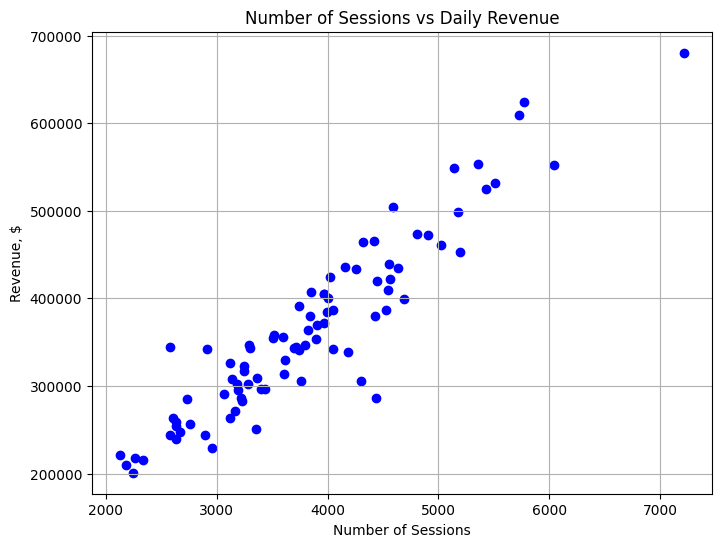

In [104]:
# Scatter Plot
plt.figure(figsize=(8,6))
plt.scatter(daily_data['ga_session_id'], daily_data['price'], color='blue')
plt.title('Number of Sessions vs Daily Revenue')
plt.xlabel('Number of Sessions')
plt.ylabel('Revenue, $')
plt.grid(True)
plt.show()

In [59]:
#data_revenue_orders_by_continent.head()
data_orders_by_3top_continent = data_orders[data_orders['continent'].isin(data_revenue_orders_by_continent['continent'])]
data_orders_by_3top_continent.head()
first_continent = data_orders_by_3top_continent["continent"].unique()[0]
second_continent = data_orders_by_3top_continent["continent"].unique()[1]
third_continent = data_orders_by_3top_continent["continent"].unique()[2]
data_orders_first_continent = data_orders_by_3top_continent[data_orders_by_3top_continent["continent"] == first_continent].groupby("date")["price"].sum().reset_index().sort_values(by = "date")
data_orders_first_continent.rename(columns={'price': f'price_{first_continent}'}, inplace=True)

data_orders_second_continent = data_orders_by_3top_continent[data_orders_by_3top_continent["continent"] == second_continent].groupby("date")["price"].sum().reset_index().sort_values(by = "date")
data_orders_second_continent.rename(columns={'price': f'price_{second_continent}'}, inplace=True)

data_orders_third_continent = data_orders_by_3top_continent[data_orders_by_3top_continent["continent"] == third_continent].groupby("date")["price"].sum().reset_index().sort_values(by = "date")
data_orders_third_continent.rename(columns={'price': f'price_{third_continent}'}, inplace=True)




data_merge_orders_by_3top_continent = data_orders_first_continent.merge(data_orders_second_continent, on='date') \
                                           .merge(data_orders_third_continent, on='date')

data_merge_orders_by_3top_continent.head()


,date,price_Americas,price_Europe,price_Asia
0,2020-11-01,132002.5,46908.0,63823.0
1,2020-11-02,193861.0,75710.8,79370.0
2,2020-11-03,294529.8,67692.0,126737.8
3,2020-11-04,200009.5,65915.0,66602.0
4,2020-11-05,182988.2,86540.0,117608.4


In [105]:
continents = data_orders_by_3top_continent["continent"].unique()
print("Correlations and p-values among the top 3 continents:")
print("Кореляції та p-value між топ-3 континентами:")

# Columns with sales in data_merge_orders_by_3top_continent
sales_columns = [f'price_{c}' for c in continents]



for i in range(len(sales_columns)):
    for j in range(i+1, len(sales_columns)):
        c1 = sales_columns[i]
        c2 = sales_columns[j]
        corr, p_value = pearsonr(data_merge_orders_by_3top_continent[c1], data_merge_orders_by_3top_continent[c2])
        print(f"{c1} vs {c2}: r = {corr:.3f}, p-value = {p_value:.5f}")


Correlations and p-values among the top 3 continents:
Кореляції та p-value між топ-3 континентами:
price_Americas vs price_Europe: r = 0.670, p-value = 0.00000
price_Americas vs price_Asia: r = 0.692, p-value = 0.00000
price_Europe vs price_Asia: r = 0.668, p-value = 0.00000


##The correlation and p-value analysis shows that sales across the top 3 continents are strongly correlated with each other.

The correlation coefficients are as follows:

price_Americas vs price_Europe: r = 0.670, p-value = 0.00000

price_Americas vs price_Asia: r = 0.692, p-value = 0.00000

price_Europe vs price_Asia: r = 0.668, p-value = 0.00000

Correlation coefficients ranging from 0.66 to 0.69 indicate a moderately strong positive correlation. In other words, when sales increase on one continent, a similar increase is observed on the others. The p-value of 0.00000 (much less than 0.05) indicates that the correlation is statistically significant, meaning these relationships are unlikely to be due to chance.

This may suggest global sales trends: for example, peak days or seasonal effects influence all continents simultaneously.

  

###Перевірка кореляції та  p-value  показує що продажі на топ-3 континентах сильно корелюють між собою:
price_Americas vs price_Europe: r = 0.670, p-value = 0.00000
price_Americas vs price_Asia: r = 0.692, p-value = 0.00000
price_Europe vs price_Asia: r = 0.668, p-value = 0.00000
Коефіцієнт r від 0.66 до 0.69 означає помірно сильну позитивну кореляцію. Тобто коли на одному континенті зростають продажі, на інших також схоже спостерігається зростання.
p-value = 0.00000 (значно менше 0.05) - кореляція статистично значуща, тобто ці зв’язки малоймовірно випадкові..
Це може свідчити про глобальні тренди у продажах: наприклад, пікові дні чи сезонні ефекти впливають на всі континенти одночасно.

In [106]:
# Total sales by channels
# data_orders_by_channels.head()
data_revenue_by_channels = data_orders.groupby('channel')['price'].sum().reset_index().sort_values(by='price', ascending=False)
channels = data_revenue_by_channels['channel'].unique()[:-1]
print("Traffic channels:\nКанали трафіку:", channels)

Traffic channels:
Канали трафіку: ['Organic Search' 'Paid Search' 'Direct' 'Social Search']


In [107]:
# Filter data for top channels only
data_orders_by_channels = data_orders[data_orders['channel'].isin(channels)]

# Create a table: date × channel → sum of sales
daily_revenue_by_channel = data_orders_by_channels.groupby(['date', 'channel'])['price'].sum().unstack(fill_value=0)
daily_revenue_by_channel = daily_revenue_by_channel[channels]  # Reorder columns
daily_revenue_by_channel.head()

channel,Organic Search,Paid Search,Direct,Social Search
date,,,,
2020-11-01,95112.0,64688.0,54669.5,25078.0
2020-11-02,127746.5,104780.8,81561.5,16843.0
2020-11-03,182521.9,152641.3,102909.5,27652.5
2020-11-04,117067.1,100332.0,79683.6,24257.4
2020-11-05,122938.4,107648.0,83367.6,41693.2


In [108]:
print("Correlations and p-values among traffic channels:")
print("Кореляції та p-value між каналами трафіку:")
for i in range(len(channels)):
    for j in range(i+1, len(channels)):
        c1 = channels[i]
        c2 = channels[j]
        corr, p_value = pearsonr(daily_revenue_by_channel[c1], daily_revenue_by_channel[c2])
        print(f"{c1} vs {c2}: r = {corr:.3f}, p-value = {p_value:.5f}")


Correlations and p-values among traffic channels:
Кореляції та p-value між каналами трафіку:
Organic Search vs Paid Search: r = 0.808, p-value = 0.00000
Organic Search vs Direct: r = 0.760, p-value = 0.00000
Organic Search vs Social Search: r = 0.434, p-value = 0.00002
Paid Search vs Direct: r = 0.724, p-value = 0.00000
Paid Search vs Social Search: r = 0.452, p-value = 0.00001
Direct vs Social Search: r = 0.462, p-value = 0.00001


##The results of the correlation analysis show a clear positive correlation between sales across different traffic channels.  

| Channel pair                  | r (coefficient) | p-value  | Conclusion                          |
|--------------------------------|----------------|----------|-------------------------------------|
| Organic Search – Paid Search    | 0.808          | 0.00000  | Strong, statistically significant  |
| Organic Search – Direct         | 0.760          | 0.00000  | Strong, significant                |
| Organic Search – Social Search  | 0.434          | 0.00002  | Moderate, significant              |
| Paid Search – Direct            | 0.724          | 0.00000  | Strong, significant                |
| Paid Search – Social Search     | 0.452          | 0.00001  | Moderate, significant              |
| Direct – Social Search          | 0.462          | 0.00001  | Moderate, significant              |

All p-values are less than 0.05, indicating that all detected correlations are statistically significant.  

The highest Pearson correlation coefficients (r ≈ 0.8, 0.76, 0.72) are observed between Organic Search, Paid Search, and Direct channels, suggesting synchronized sales fluctuations in these channels—likely due to joint marketing campaigns or seasonal peaks.  

Social Search shows moderate correlation (r ≈ 0.43–0.46), indicating somewhat different sales dynamics, likely influenced by social media activity.  

###Результати кореляційного аналізу показують чітку позитивну кореляцію між продажами за різними каналами трафіку.

| Пара каналів                  | r (коефіцієнт) | p-value  | Висновок                          |
|:-------------------------------|---------------:|---------:|:---------------------------------|
| Organic Search – Paid Search    | 0.808          | 0.00000  | Сильна, статистично значуща      |
| Organic Search – Direct         | 0.760          | 0.00000  | Сильна, значуща                  |
| Organic Search – Social Search  | 0.434          | 0.00002  | Помірна, значуща                 |
| Paid Search – Direct            | 0.724          | 0.00000  | Сильна, значуща                  |
| Paid Search – Social Search     | 0.452          | 0.00001  | Помірна, значуща                 |
| Direct – Social Search          | 0.462          | 0.00001  | Помірна, значуща                 |

Усі p-value < 0.05, отже, усі виявлені кореляції статистично значущі.

Найвищі коефіцієнти кореляції Пірсона (r ≈ 0.8, 0.76, 0.72) спостерігаються між Organic Search, Paid Search і Direct, що свідчить про спільні коливання продажів у цих каналах — можливо, через загальні маркетингові кампанії або сезонні піки.

Social Search демонструє помірну кореляцію (r ≈ 0.43–0.46), тобто має дещо відмінну динаміку продажів — ймовірно, під впливом соцмереж.


In [64]:
data_revenue_by_5top_category = data_orders.groupby("category")["price"].agg(["sum","count"]).sort_values(by = "sum", ascending = False).reset_index()[:5]
categories = data_revenue_by_5top_category['category'].unique()
print("Toп-5 категорії:", categories)

Toп-5 категорії: ['Sofas & armchairs' 'Chairs' 'Beds' 'Bookcases & shelving units'
 'Cabinets & cupboards']


In [109]:
# Filter data for top categories only
data_orders_by_categories = data_orders[data_orders['category'].isin(categories)]

# Create a table: date × category → sum of sales
daily_revenue_by_category = data_orders_by_categories.groupby(['date', 'category'])['price'].sum().unstack(fill_value=0)
daily_revenue_by_category = daily_revenue_by_category[categories]  # Reorder columns
daily_revenue_by_category.head()

category,Sofas & armchairs,Chairs,Beds,Bookcases & shelving units,Cabinets & cupboards
date,,,,,
2020-11-01,75216.0,46006.0,14041.0,36701.0,13591.5
2020-11-02,79977.5,58834.0,79683.5,40979.0,21623.0
2020-11-03,175594.0,61204.0,66219.5,64360.1,33555.5
2020-11-04,86861.5,44113.0,48939.0,35719.8,19266.0
2020-11-05,137288.0,90388.4,23449.0,40998.8,29235.0


In [110]:
print("Correlations and p-values among product categories:")
print("Кореляції та p-value між категоріями продукції:")
for i in range(len(categories)):
    for j in range(i+1, len(categories)):
        c1 = categories[i]
        c2 = categories[j]
        corr, p_value = pearsonr(daily_revenue_by_category[c1], daily_revenue_by_category[c2])
        print(f"{c1} vs {c2}: r = {corr:.3f}, p-value = {p_value:.5f}")


Correlations and p-values among product categories:
Кореляції та p-value між категоріями продукції:
Sofas & armchairs vs Chairs: r = 0.578, p-value = 0.00000
Sofas & armchairs vs Beds: r = 0.535, p-value = 0.00000
Sofas & armchairs vs Bookcases & shelving units: r = 0.666, p-value = 0.00000
Sofas & armchairs vs Cabinets & cupboards: r = 0.658, p-value = 0.00000
Chairs vs Beds: r = 0.554, p-value = 0.00000
Chairs vs Bookcases & shelving units: r = 0.637, p-value = 0.00000
Chairs vs Cabinets & cupboards: r = 0.573, p-value = 0.00000
Beds vs Bookcases & shelving units: r = 0.593, p-value = 0.00000
Beds vs Cabinets & cupboards: r = 0.515, p-value = 0.00000
Bookcases & shelving units vs Cabinets & cupboards: r = 0.539, p-value = 0.00000


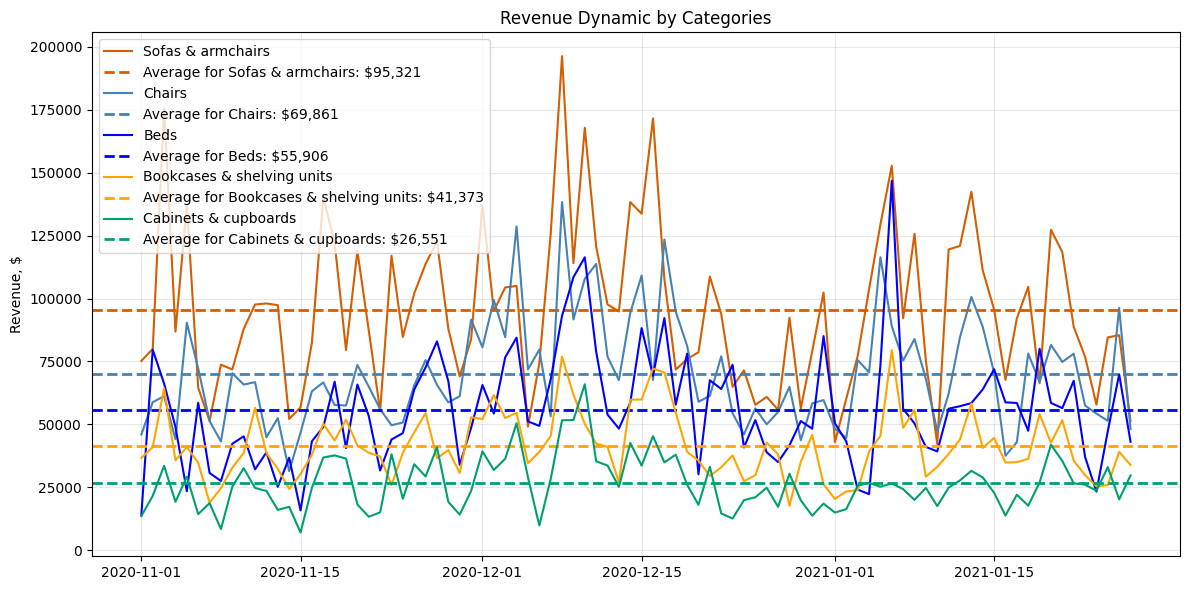

In [111]:
#Categories' Dynamic

data_orders_dynamic_by_categories = data_orders.groupby(['date', 'category'])['price'].sum().reset_index().sort_values(by = "date", ascending = True)

plt.figure(figsize=(12, 6))

color = ['#D55E00', 'steelblue', 'blue', 'orange', '#009E73']

for i in range(len(categories)):
    daily_revenue_dynamic_by_category_i =  data_orders_dynamic_by_categories[data_orders_dynamic_by_categories['category'] == categories[i]]

    plt.plot(daily_revenue_dynamic_by_category_i["date"], daily_revenue_dynamic_by_category_i["price"], label= categories[i], color= color[i])

    mean_revenue_i = daily_revenue_dynamic_by_category_i["price"].mean()# Average value
    plt.axhline(y=mean_revenue_i, color=color[i], linestyle="--", linewidth=2, label=f"Average for {categories[i]}: ${mean_revenue_i:,.0f}")

    plt.title("Revenue Dynamic by Categories")
    plt.xlabel("")
    plt.ylabel("Revenue, $")
    plt.xticks(rotation=0)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
plt.show()


In [68]:
data_order_account_registered = data_orders[data_orders['account_id'].notna()]
data_order_account_registered_date_price = data_order_account_registered.groupby('date')['price'].sum().reset_index().sort_values(by = 'date')
data_order_account_registered_date_price.rename(columns = {'price': 'sales_for_registered_users'}, inplace = True)
data_order_account_registered_date_price.head()

,date,sales_for_registered_users
0,2020-11-01,21547.0
1,2020-11-02,44956.8
2,2020-11-03,29150.5
3,2020-11-04,20982.2
4,2020-11-05,25334.6


In [69]:
#data_order_account_registrated.info()

In [70]:
#data_order_account_registered_date_price.info()

In [71]:
data_order_account_not_registered = data_orders[data_orders['account_id'].isna()]
data_order_account_not_registered_date_price = data_order_account_not_registered.groupby('date')['price'].sum().reset_index().sort_values(by = 'date')
data_order_account_not_registered_date_price.rename(columns = {'price': 'sales_for_not_registered_users'}, inplace = True)
data_order_account_not_registered_date_price.head()


,date,sales_for_not_registered_users
0,2020-11-01,222745.5
1,2020-11-02,310550.0
2,2020-11-03,469829.1
3,2020-11-04,318204.9
4,2020-11-05,365942.0


In [72]:
data_merge_account_registered_not = pd.merge(data_order_account_registered_date_price, data_order_account_not_registered_date_price, on = 'date', how = 'outer')
data_merge_account_registered_not.head()

,date,sales_for_registered_users,sales_for_not_registered_users
0,2020-11-01,21547.0,222745.5
1,2020-11-02,44956.8,310550.0
2,2020-11-03,29150.5,469829.1
3,2020-11-04,20982.2,318204.9
4,2020-11-05,25334.6,365942.0


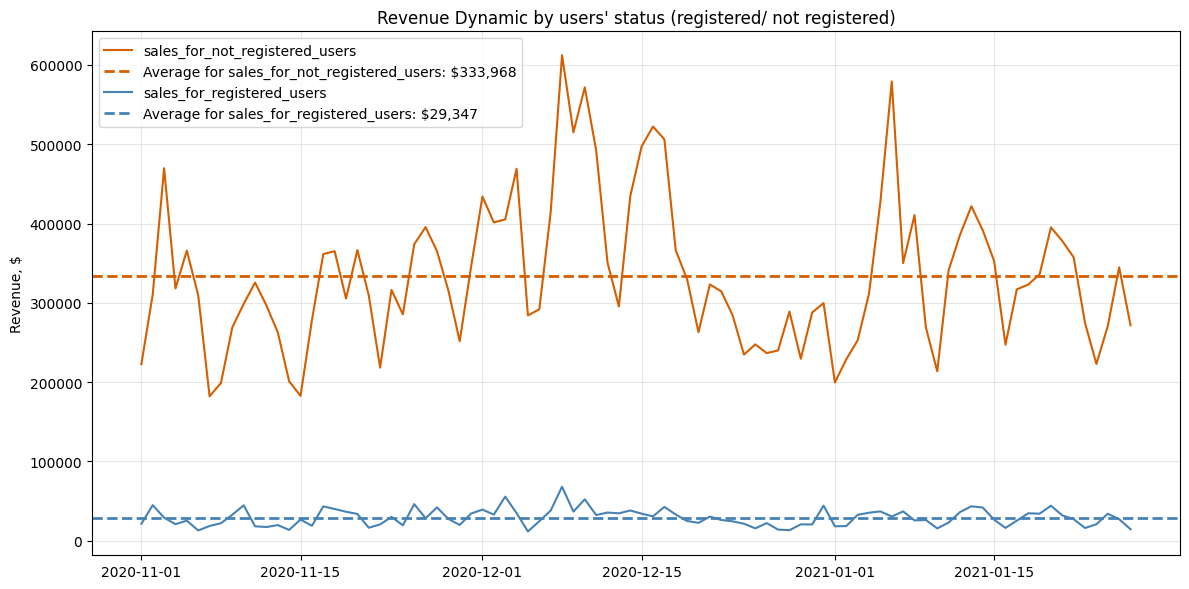

In [73]:
#Dynamic of revenue by registered/ not registered users

plt.figure(figsize=(12, 6))
columns = ['sales_for_not_registered_users', 'sales_for_registered_users']
color = ['#D55E00', 'steelblue', 'blue', 'orange', '#009E73']

for i in range(len(columns)):

    plt.plot(data_merge_account_registered_not["date"], data_merge_account_registered_not[columns[i]], label= columns[i], color= color[i])

    mean_revenue_i = data_merge_account_registered_not[columns[i]].mean()# Середнє значення з підписом у легенді
    plt.axhline(y=mean_revenue_i, color=color[i], linestyle="--", linewidth=2, label=f"Average for {columns[i]}: ${mean_revenue_i:,.0f}")

    plt.title("Revenue Dynamic by users' status (registered/ not registered)")
    plt.xlabel("")
    plt.ylabel("Revenue, $")
    plt.xticks(rotation=0)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
plt.show()

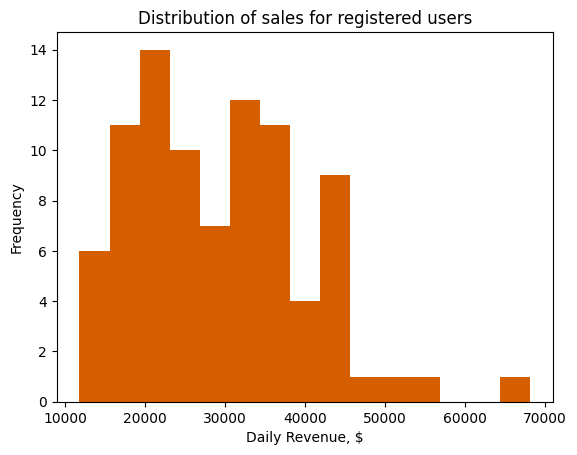

In [112]:
plt.hist(data_merge_account_registered_not['sales_for_registered_users'], bins=15, color = '#D55E00')
plt.title("Distribution of sales for registered users")
plt.xlabel('Daily Revenue, $')
plt.ylabel('Frequency')
plt.show()

In [75]:
#print("Number of rows in joined table:", {data_merge_account_registered_not['date'].count()})

In [76]:
#data_merge_account_registered_not.info()

In [77]:
# Medium-sized sample. Using D’Agostino-Pearson test to assess normality of the distribution

from scipy.stats import normaltest, shapiro
# Normaltest
_, p_value_normaltest_registered = normaltest(data_merge_account_registered_not['sales_for_registered_users'])

# Shapiro-Wilk test
#_, p_value_shapiro_registered = shapiro(data_merge_account_registered_not['sales_for_registered_users'])

# Test results
print(f"Normaltest for registered users p-value: {p_value_normaltest_registered}")

#print(f"Shapiro-Wilk for registered users p-value: {p_value_shapiro_registered}")


Normaltest for registered users p-value: 0.010929121653065912


##The distribution of revenue values obtained from registered users deviates from a normal distribution (Figure). The results of the D’Agostino-Pearson test indicate that this data distribution significantly differs from normal (p-value = 0.01).

Розподілу значень прибутку, отриманого від продажу зареєстрованим користувачам, відрізняється від нормального розподілу (Малюнок )
Результати тесту Д'агостіно_Пірсона свідчать що розподіл цих даних суттєво відрізняється від нормального (p-value = 0.01).

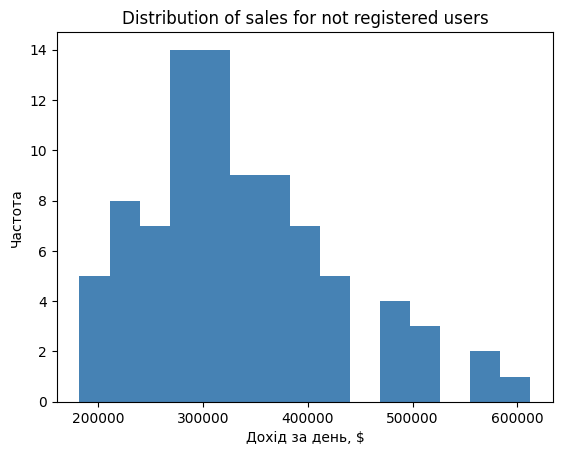

In [78]:
plt.hist(data_merge_account_registered_not['sales_for_not_registered_users'], bins=15, color = 'steelblue')
plt.title("Distribution of sales for not registered users")
plt.xlabel('Дохід за день, $')
plt.ylabel('Частота')
plt.show()

In [113]:
# Medium-sized sample. Using D’Agostino-Pearson test to assess normality of the distribution

# Normaltest
_, p_value_normaltest_not_registered = normaltest(data_merge_account_registered_not['sales_for_not_registered_users'])


# Test results
print(f"Normaltest for not registered users p-value: {p_value_normaltest_not_registered}")


Normaltest for not registered users p-value: 0.005566190512660351


##The distribution of revenue values obtained from sales to unregistered users deviates from a normal distribution (Figure). The results of the D’Agostino-Pearson test indicate that this data distribution significantly differs from normal (p-value = 0.006).

Розподілу значень прибутку, отриманого від продажу незареєстрованим користувачам, відрізняється від нормального розподілу (Малюнок ) Результати тесту Д'агостіно_Пірсона свідчать що розподіл цих даних суттєво відрізняється від нормального (p-value = 0.006).

##Since neither group follows a normal distribution, a non-parametric Mann–Whitney test should be used for comparison. If the resulting p-value < 0.05, the difference between the groups is statistically significant. If the p-value ≥ 0.05, there is no evidence to suggest that the groups differ.  


Оскільки обидві групи не є нормально розподіленими,
для порівняння слід використати непараметричний тест Манна–Вітні.
Якщо за його результатами p-value < 0.05,
→ різниця між групами статистично значуща.
Якщо p-value ≥ 0.05,
→ немає підстав вважати, що групи відрізняються.

In [114]:
from scipy.stats import mannwhitneyu

# Mann–Whitney test
stat, p_value = mannwhitneyu(
    data_merge_account_registered_not['sales_for_registered_users'],
    data_merge_account_registered_not['sales_for_not_registered_users'],
    alternative='two-sided'
)

print(f"U-statistic = {stat:.3f}")
print(f"p-value = {p_value:.5f}")

# Interpretation
alpha = 0.05
if p_value < alpha:
    print("→ The difference between the samples is statistically significant (reject H₀).")
else:
    print("→ The difference between the samples is not statistically significant (no reason to reject H₀).")

U-statistic = 0.000
p-value = 0.00000
→ The difference between the samples is statistically significant (reject H₀).


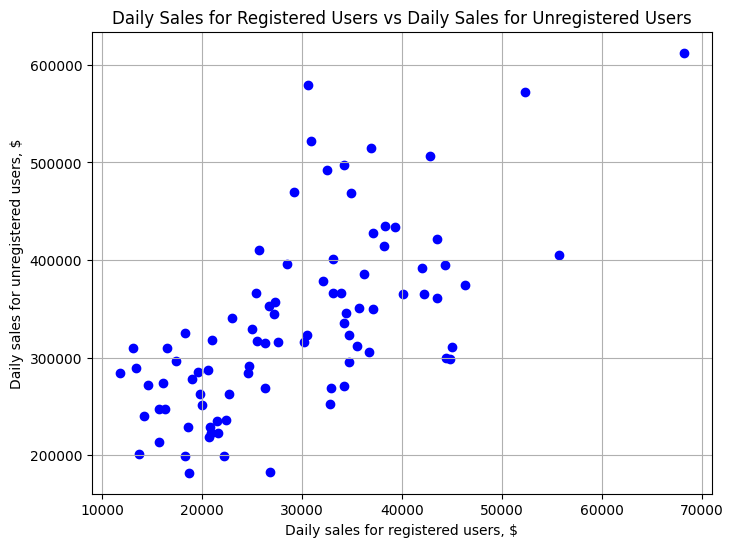

In [115]:
# Scatter plot
plt.figure(figsize=(8,6))
plt.scatter(
    data_merge_account_registered_not['sales_for_registered_users'],
    data_merge_account_registered_not['sales_for_not_registered_users'],
    color='blue'
)
plt.title('Daily Sales for Registered Users vs Daily Sales for Unregistered Users')
plt.xlabel('Daily sales for registered users, $')
plt.ylabel('Daily sales for unregistered users, $')
plt.grid(True)
plt.show()

In [116]:
#Pearson Test
corr, p_value = pearsonr(data_merge_account_registered_not['sales_for_registered_users'], data_merge_account_registered_not['sales_for_not_registered_users'])
print(f"{'sales_for_registered_users'} vs {'sales_for_not_registered_users'}: r = {corr:.3f}, p-value = {p_value:.5f}")


sales_for_registered_users vs sales_for_not_registered_users: r = 0.659, p-value = 0.00000


##Pearson correlation coefficient (r = 0.659) -  a fairly strong positive relationship between sales for registered and unregistered users.
In other words, when sales among registered users increase, sales among unregistered users usually increase as well.

p-value = 0.00000 (< 0.05) - the result is statistically significant, meaning the relationship is unlikely to be due to chance.  

Коефіцієнт кореляції Пірсона (r = 0.659) - досить сильний додатний зв’язок між продажами для зареєстрованих і незареєстрованих користувачів.
Тобто, коли зростають продажі серед зареєстрованих, зазвичай зростають і серед незареєстрованих.

p-value = 0.00000 (< 0.05) - результат статистично значущий, тобто зв’язок не випадковий.

In [83]:
data_session_dynamic_by_channels_number = data.groupby(["date", "channel"])["ga_session_id"].count().sort_values(ascending = True).unstack(fill_value=0)
data_session_dynamic_by_channels_number.head()

channel,Direct,Organic Search,Paid Search,Social Search,Undefined
date,,,,,
2020-11-01,608,920,706,214,128
2020-11-02,810,1242,970,315,262
2020-11-03,1216,1871,1367,392,327
2020-11-04,935,1425,1145,368,311
2020-11-05,845,1293,917,346,342


In [84]:
# Medium-sized sample. Using D’Agostino-Pearson test to assess distribution normality

# Normaltest
channels = sorted(data["channel"].unique())

for i in range(len(channels)):
    _, p_value_normaltest_i = normaltest(data_session_dynamic_by_channels_number[channels[i]])

    # Test results
    print(f"Normaltest for {channels[i]} channel p-value: {p_value_normaltest_i}")


Normaltest for Direct channel p-value: 0.007853358264896217
Normaltest for Organic Search channel p-value: 0.0031046084804515037
Normaltest for Paid Search channel p-value: 0.0016504167955096551
Normaltest for Social Search channel p-value: 0.21439918696878835
Normaltest for Undefined channel p-value: 0.0402046864129123


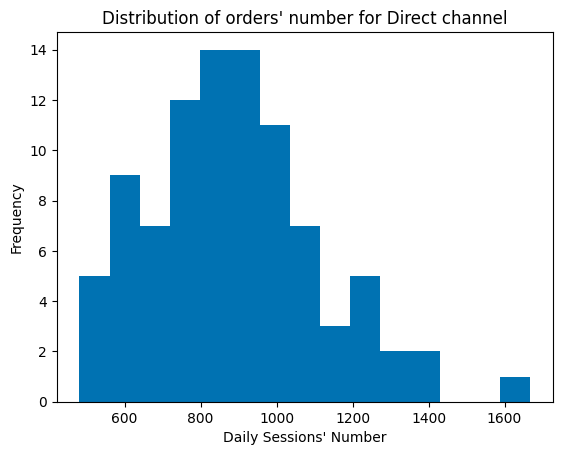

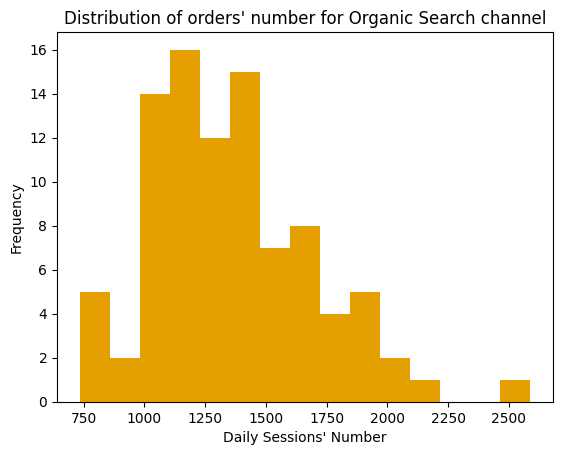

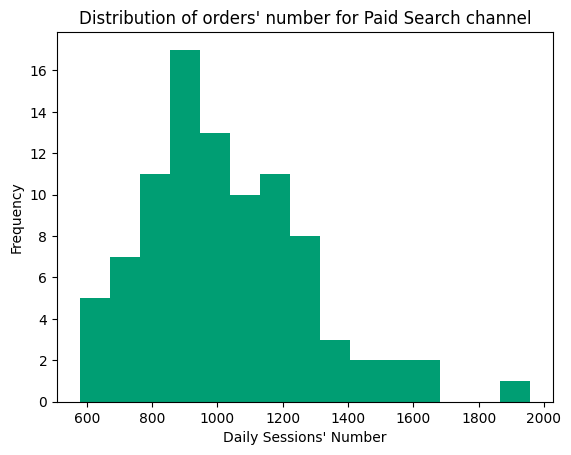

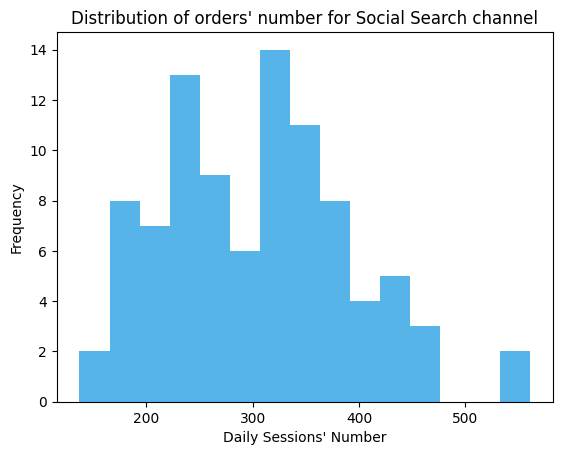

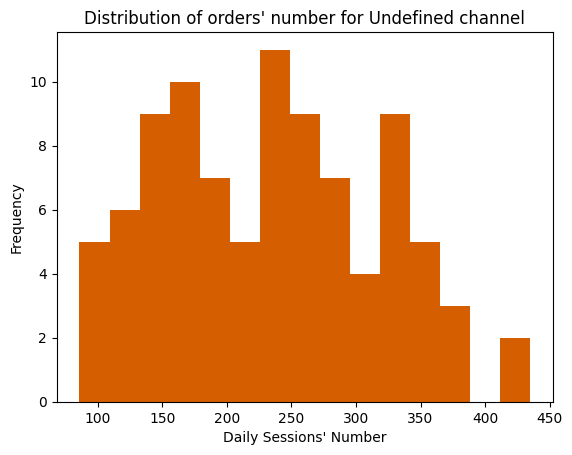

In [85]:
#channels = data["channel"].unique()

for i in range(len(channels)):
    channel = channels[i]
    plt.hist(data_session_dynamic_by_channels_number[channel], bins = 15, color = colors[i])
    plt.title(f"Distribution of orders' number for {channel} channel")
    plt.xlabel("Daily Sessions' Number")
    plt.ylabel("Frequency")
    plt.show()

In [86]:
from scipy.stats import kruskal

stat, p = kruskal(
    data_session_dynamic_by_channels_number['Direct'],
    data_session_dynamic_by_channels_number['Organic Search'],
    data_session_dynamic_by_channels_number['Paid Search'],
    data_session_dynamic_by_channels_number['Social Search'],
    data_session_dynamic_by_channels_number['Undefined']
)
print(f"Kruskal–Wallis test p-value: {p:.5f}")

Kruskal–Wallis test p-value: 0.00000


###The distribution of session counts across other channels is not normal (p-value < 0.05).
Given this, the Kruskal–Wallis test was used for further analysis of the relationships between datasets, which showed statistically significant differences between groups.
For pairwise comparisons of groups, the Mann–Whitney U test was applied.  
  



Розподіл значень кількості сесій в розрізі інших каналів не є нормальним (p-value < 0.05).
Враховуючи вищевикладене, для подальшого аналізу взаємозв’язку між наборами даних використано тест Краскела–Волліса (Kruskal–Wallis test), результати якого показали статистично значущі відмінності між групами.
Для попарного порівняння груп використано Манна-Уитни тест (Mann–Whitney U test).

In [87]:
import itertools

channels = ['Direct', 'Organic Search', 'Paid Search', 'Social Search', 'Undefined']

for c1, c2 in itertools.combinations(channels, 2):
    stat, p = mannwhitneyu(
        data_session_dynamic_by_channels_number[c1],
        data_session_dynamic_by_channels_number[c2]
    )
    print(f"{c1} vs {c2}: p-value = {p:.5f}")

Direct vs Organic Search: p-value = 0.00000
Direct vs Paid Search: p-value = 0.00012
Direct vs Social Search: p-value = 0.00000
Direct vs Undefined: p-value = 0.00000
Organic Search vs Paid Search: p-value = 0.00000
Organic Search vs Social Search: p-value = 0.00000
Organic Search vs Undefined: p-value = 0.00000
Paid Search vs Social Search: p-value = 0.00000
Paid Search vs Undefined: p-value = 0.00000
Social Search vs Undefined: p-value = 0.00000



###For pairwise group comparisons, the Mann–Whitney U test was used. The resulting p-values (p-value = 0.00) indicate statistically significant differences between all groups.  

Для попарного порівняння груп використано Манна-Уитни тест (Mann–Whitney U test).  Отримані коефіцієнти (p-value = 0.00) показують статистично значущі відмінності між усіма групами.

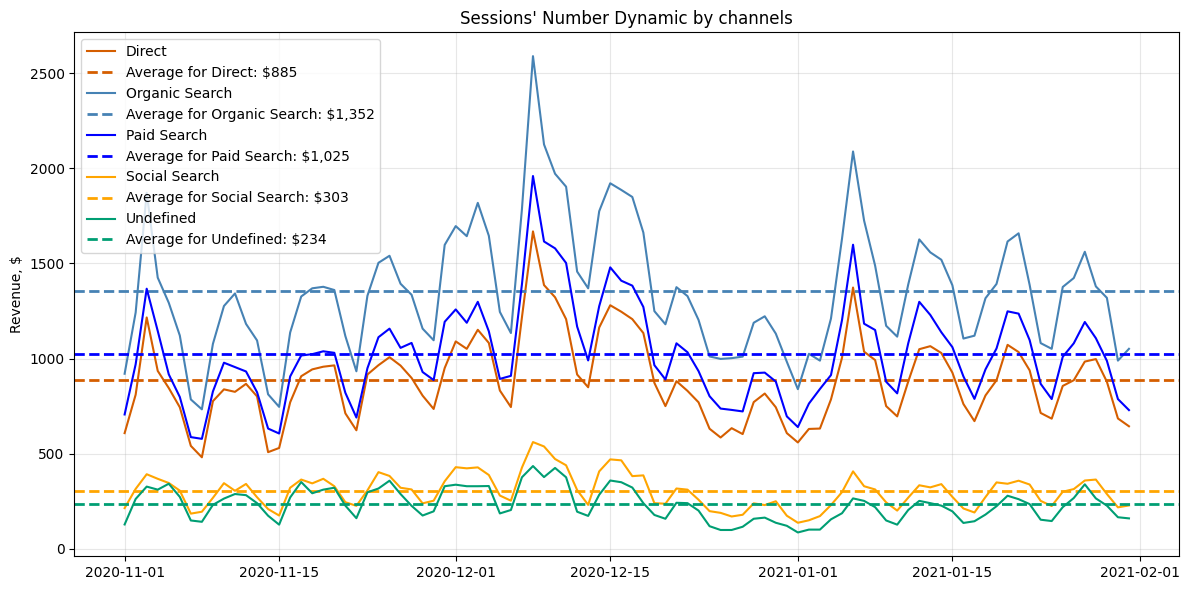

In [88]:
#Dynamic of sessions' number by channels
data_session_dynamic_by_channels_number = data_session_dynamic_by_channels_number.reset_index()
plt.figure(figsize=(12, 6))

for i in range(len(channels)):

    plt.plot(data_session_dynamic_by_channels_number["date"], data_session_dynamic_by_channels_number[channels[i]], label= channels[i], color= color[i])

    mean_revenue_i = data_session_dynamic_by_channels_number[channels[i]].mean()# Середнє значення з підписом у легенді
    plt.axhline(y=mean_revenue_i, color=color[i], linestyle="--", linewidth=2, label=f"Average for {channels[i]}: ${mean_revenue_i:,.0f}")

    plt.title("Sessions' Number Dynamic by channels")
    plt.xlabel("")
    plt.ylabel("Revenue, $")
    plt.xticks(rotation=0)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
plt.show()

In [89]:
from scipy.stats import spearmanr

# Create an empty DataFrame to store the results
corr_matrix = pd.DataFrame(index=channels, columns=channels, dtype=float)
pvalue_matrix = pd.DataFrame(index=channels, columns=channels, dtype=float)

# Calculate pairwise Spearman correlation
for ch1 in channels:
    for ch2 in channels:
        corr, pval = spearmanr(
            data_session_dynamic_by_channels_number[ch1],
            data_session_dynamic_by_channels_number[ch2]
        )
        corr_matrix.loc[ch1, ch2] = corr
        pvalue_matrix.loc[ch1, ch2] = pval

print("Spearman correlation matrix:")
print(corr_matrix)

print("\n P-value matrix:")
print(pvalue_matrix)

Spearman correlation matrix:
                  Direct  Organic Search  Paid Search  Social Search  \
Direct          1.000000        0.978067     0.976252       0.921550   
Organic Search  0.978067        1.000000     0.984479       0.899453   
Paid Search     0.976252        0.984479     1.000000       0.894384   
Social Search   0.921550        0.899453     0.894384       1.000000   
Undefined       0.830998        0.797575     0.785163       0.935412   

                Undefined  
Direct           0.830998  
Organic Search   0.797575  
Paid Search      0.785163  
Social Search    0.935412  
Undefined        1.000000  

 P-value matrix:
                      Direct  Organic Search   Paid Search  Social Search  \
Direct          0.000000e+00    4.101667e-63  1.412000e-61   9.533236e-39   
Organic Search  4.101667e-63    0.000000e+00  8.232619e-70   4.106311e-34   
Paid Search     1.412000e-61    8.232619e-70  0.000000e+00   3.347998e-33   
Social Search   9.533236e-39    4.106311e-34

###All r coefficients > 0.78, with most even above 0.9. This indicates:

a very strong positive relationship between session dynamics across different channels;

in other words, when the number of sessions in one channel increases, it almost always increases in others as well.

P-value

All p-values ≪ 0.05 (even 10⁻³³ and smaller — practically 0).
→ All correlations are statistically significant.

Conclusion

The dynamics of session counts across all channels show a strong and statistically significant positive relationship.
This suggests that fluctuations in user activity across different channels occur synchronously — likely influenced by common factors such as seasonality, marketing campaigns, news, etc.  



Всі коефіцієнти r > 0.78, більшість — навіть 0.9+.
Це означає:

дуже сильний позитивний зв’язок між динамікою сеансів у різних каналах;

тобто, коли кількість сесій у якомусь каналі зростає — вона майже завжди зростає й в інших.

 P-value

Усі p-value ≪ 0.05
(навіть 10⁻³³ і менші — тобто практично 0).
→ Усі кореляції статистично значущі.
 Висновок

Динаміка кількості сесій між усіма каналами має сильний і статистично значущий позитивний зв’язок.
Це свідчить про те, що коливання активності користувачів у різних каналах відбуваються синхронно — ймовірно, під впливом загальних факторів (сезонність, маркетингові кампанії, новини тощо).

In [90]:
data_date_continent_channel = data.groupby(["date", "continent", "channel"])["ga_session_id"].count().reset_index().sort_values(by = "date")
data_date_continent_channel.rename(columns = {"ga_session_id": "sessions_number"}, inplace =True)
data_date_continent_channel.head()


,date,continent,channel,sessions_number
0,2020-11-01,(not set),Paid Search,1
25,2020-11-01,Oceania,Social Search,3
24,2020-11-01,Oceania,Paid Search,8
23,2020-11-01,Oceania,Organic Search,8
22,2020-11-01,Oceania,Direct,4


In [91]:
data_date_channel = data.groupby("date")["ga_session_id"].count().reset_index().sort_values(by = "date", ascending = True)
data_date_channel.rename(columns = {"ga_session_id": "total_sessions_number_per_day"}, inplace = True)

data_date_channel.head()

,date,total_sessions_number_per_day
0,2020-11-01,2576
1,2020-11-02,3599
2,2020-11-03,5173
3,2020-11-04,4184
4,2020-11-05,3743


In [92]:
data_date_continent_channel_total = pd.merge(data_date_continent_channel, data_date_channel, on = "date", how = "inner")
data_date_continent_channel_total["ratio_sessions_number_to_total"] = data_date_continent_channel_total["sessions_number"] / data_date_continent_channel_total["total_sessions_number_per_day"] * 100
data_date_continent_channel_total.head()

,date,continent,channel,sessions_number,total_sessions_number_per_day,ratio_sessions_number_to_total
0,2020-11-01,(not set),Paid Search,1,2576,0.03882
1,2020-11-01,Oceania,Social Search,3,2576,0.11646
2,2020-11-01,Oceania,Paid Search,8,2576,0.310559
3,2020-11-01,Oceania,Organic Search,8,2576,0.310559
4,2020-11-01,Oceania,Direct,4,2576,0.15528


In [93]:
data_date_continent_channel_total_eur_amer = data_date_continent_channel_total[((data_date_continent_channel_total["continent"] == "Europe") | (data_date_continent_channel_total["continent"] == "Americas"))]
data_date_continent_channel_total_eur_amer_organic = data_date_continent_channel_total_eur_amer[data_date_continent_channel_total_eur_amer["channel"] == "Organic Search"]
data_date_continent_channel_total_eur_amer_organic.head(10)

,date,continent,channel,sessions_number,total_sessions_number_per_day,ratio_sessions_number_to_total
7,2020-11-01,Europe,Organic Search,170,2576,6.599379
22,2020-11-01,Americas,Organic Search,534,2576,20.729814
27,2020-11-02,Europe,Organic Search,228,3599,6.335093
49,2020-11-02,Americas,Organic Search,654,3599,18.171714
54,2020-11-03,Europe,Organic Search,340,5173,6.572588
80,2020-11-03,Americas,Organic Search,981,5173,18.963851
86,2020-11-04,Europe,Organic Search,267,4184,6.381453
107,2020-11-04,Americas,Organic Search,799,4184,19.096558
116,2020-11-05,Europe,Organic Search,259,3743,6.919583
139,2020-11-05,Americas,Organic Search,700,3743,18.701576


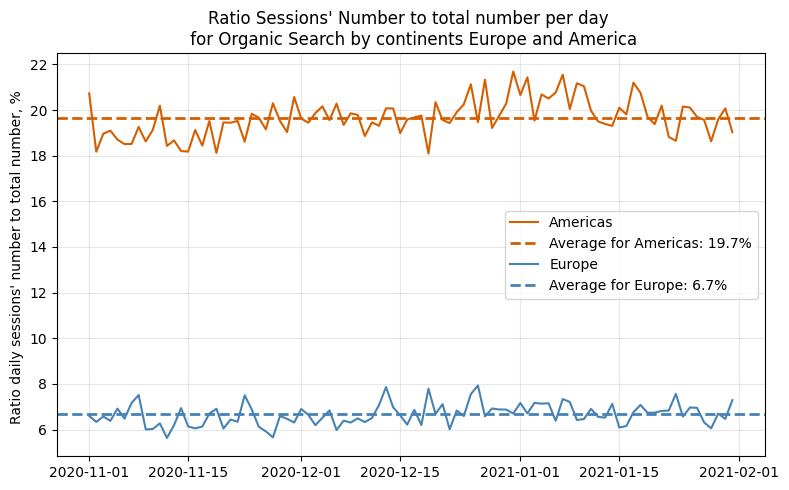

In [94]:
continents = ["Americas", "Europe"]
plt.figure(figsize=(8, 5))
for i in range(len(continents)):
    data_plot = data_date_continent_channel_total_eur_amer_organic[data_date_continent_channel_total_eur_amer_organic["continent"] == continents[i]]
    plt.plot(data_plot["date"], data_plot["ratio_sessions_number_to_total"], label= continents[i], color= color[i])

    mean_revenue_i = data_plot["ratio_sessions_number_to_total"].mean()# Середнє значення з підписом у легенді
    plt.axhline(y=mean_revenue_i, color=color[i], linestyle="--", linewidth=2, label=f"Average for {continents[i]}: {mean_revenue_i:,.1f}%")

    plt.title("Ratio Sessions' Number to total number per day \n for Organic Search by continents Europe and America")
    plt.xlabel("")
    plt.ylabel("Ratio daily sessions' number to total number, % ")
    plt.xticks(rotation=0)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
plt.show()

In [95]:
# Medium-sized sample. Using the D’Agostino-Pearson test to assess distribution normality

# Normaltest

for i in range(len(continents)):
    data_plot = data_date_continent_channel_total_eur_amer_organic[data_date_continent_channel_total_eur_amer_organic["continent"] == continents[i]]
    _, p_value_normaltest_i = normaltest(data_plot["ratio_sessions_number_to_total"])

    # Test results
    print(f"Normaltest for Organic Search in {continents[i]} p-value: {p_value_normaltest_i}")


Normaltest for Organic Search in Americas p-value: 0.5062950010123896
Normaltest for Organic Search in Europe p-value: 0.27783666042977556


###The sales distributions for Organic Search in the Americas and Europe can be considered normal.  

Розподіли продажів для Organic Search в Америці та Європі можна вважати нормальними.

In [96]:
from scipy.stats import pearsonr
data_americas = data_date_continent_channel_total_eur_amer_organic[data_date_continent_channel_total_eur_amer_organic["continent"] == "Americas"]

data_europe = data_date_continent_channel_total_eur_amer_organic[data_date_continent_channel_total_eur_amer_organic["continent"] == "Europe"]
corr, p_value = pearsonr(
    data_americas["ratio_sessions_number_to_total"],
    data_europe["ratio_sessions_number_to_total"]
)

print(f"Pearson correlation: r = {corr:.3f}, p-value = {p_value:.5f}")

Pearson correlation: r = 0.088, p-value = 0.40434


/tmp/ipython-input-2918789321.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_americas.rename(columns={"ratio_sessions_number_to_total": "ratio_organic_to_total_americas"}, inplace=True)
/tmp/ipython-input-2918789321.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_europe.rename(columns={"ratio_sessions_number_to_total": "ratio_organic_to_total_europe"}, inplace=True)


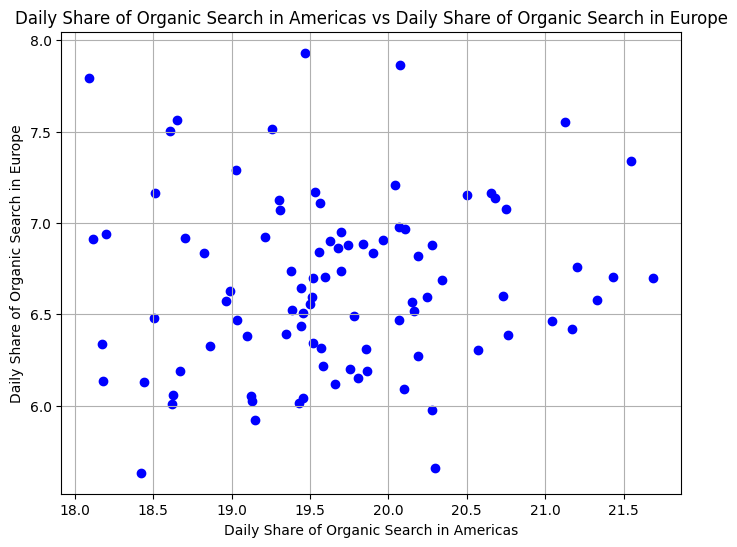

In [117]:
# Scatter plot
data_americas.rename(columns={"ratio_sessions_number_to_total": "ratio_organic_to_total_americas"}, inplace=True)
data_europe.rename(columns={"ratio_sessions_number_to_total": "ratio_organic_to_total_europe"}, inplace=True)

data_organic_merge = pd.merge(data_americas, data_europe, on='date', how="outer")

plt.figure(figsize=(8,6))
plt.scatter(
    data_organic_merge['ratio_organic_to_total_americas'],
    data_organic_merge['ratio_organic_to_total_europe'],
    color='blue'
)
plt.title('Daily Share of Organic Search in Americas vs Daily Share of Organic Search in Europe')
plt.xlabel('Daily Share of Organic Search in Americas')
plt.ylabel('Daily Share of Organic Search in Europe')
plt.grid(True)
plt.show()

###As a result of the statistical analysis of session dynamics and sales across different continents, traffic channels, and product categories, the following was established:
Distribution Normality  

For most samples, the distribution of metrics did not follow a normal distribution (D’Agostino–Pearson test, p < 0.05), which required the use of non-parametric methods (specifically, the Kruskal–Wallis test) for group comparisons.  
  
In cases where samples were normally distributed, parametric analysis was applied (Pearson correlation, t-test).  

Comparison of Continents  

Sales among the top three continents (Americas, Europe, Asia) showed a moderately strong positive correlation (r ≈ 0.67–0.69, p < 0.001), indicating aligned trends in demand across different markets.  

Comparison of Traffic Channels  

Among the main channels (Organic, Paid, Direct, Social), a high positive correlation was observed (r ≈ 0.7–0.8, p < 0.001), meaning that an increase in activity in one channel is accompanied by increases in others. This may indicate synergy between marketing channels.  

Comparison of Product Categories  

Sales across main product categories also showed moderate positive correlation (r ≈ 0.5–0.6, p < 0.001), suggesting shared seasonality or consumer behavior patterns.  

Registered vs. Non-registered Users  

A significant positive correlation was found between sales for both groups (r ≈ 0.66, p < 0.001), which may reflect general demand trends regardless of user status.  

Organic Search: Americas vs. Europe  

The Pearson test (r = 0.088, p = 0.404) indicated no statistically significant relationship between the metrics of the two regions—their dynamics are likely driven by different market conditions.  

###Overall Conclusion  

The analysis demonstrated strong positive relationships across most channels, categories, and continents, indicating an interconnected structure of sales and traffic.  

At the same time, some markets (notably, Americas and Europe for the Organic Search channel) exhibit independent behavior, possibly reflecting different marketing or consumer characteristics.  

These results should be considered when planning campaigns targeting specific regions or user segments.

У результаті проведеного статистичного аналізу даних щодо динаміки сесій та продажів за різними континентами, каналами трафіку та категоріями продукції було встановлено таке:

Нормальність розподілу  

Для більшості вибірок розподіл показників не відповідав нормальному закону (за тестом Д’Агостіно–Пірсона, p < 0.05), що зумовило використання непараметричних методів (зокрема, тесту Крускала–Волліса) для порівняння груп.
У випадках, коли вибірки мали нормальний розподіл, застосовувався параметричний аналіз (тест Пірсона, t-тест).

Порівняння континентів  

Продажі між топ-3 континентами (Americas, Europe, Asia) виявили помірно сильну позитивну кореляцію (r ≈ 0.67–0.69, p < 0.001), що свідчить про узгоджені тенденції змін попиту на різних ринках.

Порівняння каналів трафіку  

Між основними каналами (Organic, Paid, Direct, Social) виявлено високу позитивну кореляцію (r ≈ 0.7–0.8, p < 0.001), тобто зростання активності в одному каналі супроводжується підвищенням у решті. Це може свідчити про синергію маркетингових каналів.

Порівняння категорій продукції  

Продажі між основними категоріями товарів також мають помірну позитивну кореляцію (r ≈ 0.5–0.6, p < 0.001), що вказує на спільну сезонність або поведінкові закономірності споживачів.

Зареєстровані vs незареєстровані користувачі  

Виявлено істотну позитивну кореляцію між продажами обох груп (r ≈ 0.66, p < 0.001), що може відображати загальні тренди попиту незалежно від статусу користувача.

Organic Search: Americas vs Europe  

Тест Пірсона (r = 0.088, p = 0.404) показав відсутність статистично значущого зв’язку між показниками двох регіонів — їхня динаміка, ймовірно, визначається різними ринковими умовами.

###Загальний висновок

Аналіз показав наявність стійких позитивних взаємозв’язків між більшістю каналів, категорій і континентів, що свідчить про взаємопов’язану структуру продажів та трафіку.
Разом з тим, окремі ринки (зокрема, Americas та Europe у каналі Organic Search) демонструють незалежну поведінку, що може бути ознакою різних маркетингових або споживчих особливостей.
Отримані результати доцільно враховувати при плануванні кампаній, орієнтованих на конкретні регіони чи сегменти користувачів.

In [98]:
data.to_csv('temp1.csv', index=False)
!ls /content


sample_data  temp1.csv


In [99]:
from google.colab import drive
drive.mount('/content/drive')
data.to_csv('/content/drive/MyDrive/temp1.csv', index=False)

Mounted at /content/drive
